# Proyecto de Datos 1 - MMD4001
**Integrantes: Constanza Lizama S. y Constanza Miranda G.**

Profesor: Stefan Escaida.

Primer semestre 2025

---
## Librerías necesarias

In [91]:
import IMProToo
import xarray as xr
from matplotlib import cm, colors
import matplotlib.pyplot as plt
import proplot as pplt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta   
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
from matplotlib.patches import Rectangle
from matplotlib import dates
import seaborn as sns

sns.set(style="whitegrid")
sns.set_context("notebook", rc={"legend.fontsize":8})

---
## Datos

In [92]:
#ds= xr.open_dataset('C:/Users/conym/Desktop/ing/semestre 7/proyecto de datos/0806_mrr2c.nc_1.nc')
ds = xr.open_dataset('C:/Cosas/Universidark/Proyecto de Datos 1/Datos/0806_mrr2c.nc_1.nc')

ds_0521 = xr.open_dataset('C:/Cosas/Universidark/Proyecto de Datos 1/Datos/0521_mrr2c.nc_2.nc')
#ds_0521= xr.open_dataset('C:/Users/conym/Desktop/ing/SEMESTRE 7/proyecto de datos/0521_mrr2c.nc_2.nc')

ds_0614 = xr.open_dataset('C:/Cosas/Universidark/Proyecto de Datos 1/Datos/0614_mrr2c.nc_2.nc')
#ds_0614= xr.open_dataset('C:/Users/conym/Desktop/ing/SEMESTRE 7/proyecto de datos/0614_mrr2c.nc_2.nc')

ds_0622 = xr.open_dataset('C:/Cosas/Universidark/Proyecto de Datos 1/Datos/0622_mrr2c.nc_2.nc')
#ds_0622 = xr.open_dataset('C:/Users/conym/Desktop/ing/SEMESTRE 7/proyecto de datos/0622_mrr2c.nc_2.nc')

ds_0801 = xr.open_dataset('C:/Cosas/Universidark/Proyecto de Datos 1/Datos/0801_mrr2c.nc_2.nc')
#ds_0801= xr.open_dataset('C:/Users/conym/Desktop/ing/SEMESTRE 7/proyecto de datos/0801_mrr2c.nc_2.nc')

---

## Funciones

#### Ploteo base

In [93]:
# Paletas de colores
paleta0 = ['#ccd8ff','#3366ff','#9fdf9f','#00b300','#ffff00','#ffcc30','#e62e00','#ff6600','#fff0e5','#c03fc0','#602060']
paleta1 = ['#ffe5d9','#ffb3b3','#ffcc99','#ffffcc','#ccffcc','#b3e0ff','#b3b3ff','#e5ccff','#ffcce5','#ffd9b3','#ffe5b3']
paleta2 = ['#390099','#6C0079','#9E0059','#CF0057','#FF0054','#FF2A2A','#FF5400','#FF8900','#FFBD00','#FFC317','#FFC82C']
paleta3 = ['#000814','#001329','#001D3D','#002952','#003566','#40594D','#807C33','#A08E27','#C0A01A','#FFC300','#FFD60A']

def add_no_data(ax, times, xlim):
    """Añade área de 'Sin Datos' al gráfico"""
    # Obtener límites actuales del gráfico
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    # Verificar si realmente no hay datos
    if len(times) == 0 or (xlim is not None and (times[-1] < xlim[0] or times[0] > xlim[1])):
        # Crear rectángulo sombreado
        rect = plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                           fill=False, hatch='////', edgecolor='gray3',
                           linewidth=0, zorder=10, alpha=0.5)
        ax.add_patch(rect)
        
        # Añadir texto centrado
        ax.text((xmin+xmax)/2, (ymin+ymax)/2, 'SIN DATOS',
               color='red', ha='center', va='center',
               fontsize=12, weight='bold', zorder=11,
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
def plot_mrr2(xlim, times, heights, Ze, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex=paleta0):
    # Configuración de colormap
    cmap4 = list(zip(np.linspace(0, 1, len(colorhex)), colorhex))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom", cmap4)
    dbzmap.set_bad('0.9', 1)
    bounds = np.arange(-5, 50, 1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    # Configuración de ejes
    xlabel = r'Hora Local $\rightarrow$' if hora_local else r'Hora UTC $\rightarrow$'
    ylim = [0, 3600] if heights[-1] < 5000 else [0, 8000]

    # Conversión de tiempos a numérico
    times_num = dates.date2num(times)
    xmin, xmax = (dates.date2num(xlim) if xlim != ''
                  else (times_num[0], times_num[-1]))

    # Cálculo de la extensión para imshow
    dx = (times_num[-1] - times_num[0]) / (len(times_num) - 1) if len(times_num) > 1 else 0
    dy = (heights[-1] - heights[0]) / (len(heights) - 1) if len(heights) > 1 else 0

    extent = [
        times_num[0] - dx/2,  # xmin
        times_num[-1] + dx/2,  # xmax
        heights[0] - dy/2,     # ymin
        heights[-1] + dy/2     # ymax
    ]

    # Configuración de ticks según duración
    total_seconds = (xlim[1] - xlim[0]).total_seconds()
    if total_seconds <= 14400:  # ≤ 4 horas
        xlocator = ('hour', range(0, 24, 1))
        xminorlocator = ('minute', 30)
    elif 14400 < total_seconds <= 82800:  # 4-23 horas
        xlocator = ('hour', range(0, 24, 3))
        xminorlocator = ('hour', range(0, 24, 1))
    else:  # > 23 horas
        xlocator = ('hour', range(0, 24, 6))
        xminorlocator = ('hour', range(0, 24, 2))

    if Vf is None:
        # Configuración para un solo gráfico (solo reflectividad)
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze.T,  # Transponer para orientación correcta
                      extent=extent,
                      aspect='auto',
                      origin='lower',
                      norm=norm,
                      cmap=dbzmap,
                      interpolation='nearest')

        ax.format(ultitle='Reflectividad Equivalente',
                xrotation=False,
                xformatter='concise',
                xlocator=xlocator,
                xminorlocator=xminorlocator,
                ylim=ylim,
                yticklabelloc=ytickloc,
                ytickloc='both',
                xticklabelsize=8,
                suptitle='Radar Perfilador MRR en UOH Rancagua',
                ylabel='Altitud [msnm]',
                xlabel=xlabel)
        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

    else:
        # Configuración para dos gráficos (reflectividad y velocidad)
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3, sharex=True)

        # Gráfico de reflectividad
        mZe = ax[0].imshow(Ze.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         norm=norm,
                         cmap=dbzmap,
                         interpolation='nearest')
        add_no_data(ax[0], times, xlim)

        # Gráfico de velocidad
        mVf = ax[1].imshow(Vf.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         vmin=-3, vmax=10,
                         cmap='RdBu',
                         interpolation='nearest')
        add_no_data(ax[1], times, xlim)

        # Formateo del primer gráfico
        ax[0].format(ultitle='Reflectividad Equivalente',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8,
                   suptitle='Radar Perfilador MRR en UOH Rancagua',
                   ylabel='Altitud [msnm]',
                   xlabel=xlabel)
        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        # Formateo del segundo gráfico
        ax[1].format(ultitle='Velocidad de caída',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8)
        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4, extend='both')

    # Ajustar límites de tiempo si se especificaron
    if xlim != '':
        if Vf is None:
            ax.format(xlim=xlim)
        else:
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

#### Ruido

In [94]:
def ruido(Ze, Vf):
    Ze_filtered = Ze.where(Ze >= 12, 12)
    Vf_filtered = np.where(Ze >= 12, Vf, 2)
    return Ze_filtered, Vf_filtered

#### Ploteo gradiente 

In [95]:
def plot_mrr3_imshow(xlim, times, heights, Ze, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex = paleta0):
    cmap4 = []
    stops = [0,1./10,2./10,3./10,4./10,5./10,6./10,7./10,8./10,9./10,1]
    for value, color in zip(stops,colorhex):
        cmap4.append((value,color))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom",cmap4)
    dbzmap.set_bad('0.9',1)
    bounds = np.arange(-5,50,1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    if hora_local:
        xlabel = r'Hora Local $\rightarrow$'
    else:
        xlabel = r'Hora UTC $\rightarrow$'

    if heights[-1]< 5000:
        ylim = [0, 3600]
    else:
        ylim = [0, 8000]

    total_seconds = (xlim[1]-xlim[0]).total_seconds()

    if total_seconds <= 14400:
        xlocator=('hour',range(0,24,1))
        xminorlocator=('minute',30)
    elif (total_seconds>14400) and (total_seconds<=82800.0):
        xlocator=('hour',range(0,24,3))
        xminorlocator=('hour',range(0,24,1))
    else:
        xlocator=('hour',range(0,24,6))
        xminorlocator=('hour',range(0,24,2))

    extent = [dates.date2num(times[0]), dates.date2num(times[-1]), heights[0], heights[-1]]

    if Vf is None:

        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze, origin='lower', aspect='auto',
                        cmap=dbzmap, norm=norm,
                        extent=extent)

        ax.format(ultitle='Reflectividad Equivalente',
                  xrotation=False,
                  xformatter='concise',
                  xlocator=xlocator,
                  xminorlocator=xminorlocator,
                  ylim=ylim,
                  yticklabelloc=ytickloc,
                  ytickloc='both',
                  xticklabelsize=8,
                  suptitle='Gradientes datos MRR UOH',
                  ylabel='Altitud [msnm]',
                  xlabel=xlabel)

        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

        if xlim != '':
            ax.format(xlim=xlim)

    else:
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3)

        mZe = ax[0].imshow(Ze, origin='lower', aspect='auto',
                           cmap=dbzmap, norm=norm,
                           extent=extent)
        add_no_data(ax[0], times, xlim)

        mVf = ax[1].imshow(Vf, origin='lower', aspect='auto',
                           vmin=-3, vmax=10,
                           cmap='RdBu',
                           extent=extent)
        add_no_data(ax[1], times, xlim)

        ax[0].format(ultitle='Reflectividad Equivalente',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8,
                     suptitle='Gradientes datos MRR UOH',
                     ylabel='Altitud [msnm]',
                     xlabel=xlabel)

        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        ax[1].format(ultitle='Velocidad de caída',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8)

        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4,
                       extend='both')

        if xlim != '':
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

    fig.show()


#### Cálculo del gradiente (Función base)

In [96]:
def calcular_gradiente(datos, marco):
    pesos = np.array([marco - i for i in range(marco)])  
    pesos = pesos / np.sum(pesos)                        
    niveles_restantes = datos.shape[0] - 1 - 2 * (marco - 1)
    gradiente_datos = np.zeros((niveles_restantes, datos.shape[1]))

    for i in range(marco, datos.shape[0] - marco):
        superior = np.sum([pesos[j] * datos[i + j, :] for j in range(marco)], axis=0)
        inferior = np.sum([pesos[j] * datos[i - j - 1, :] for j in range(marco)], axis=0)
        gradiente_datos[i - marco, :] = superior - inferior

    filas_superior = marco
    filas_inferior = marco - 1

    gradiente_datos_completo = np.pad(gradiente_datos, ((filas_superior, filas_inferior), (0, 0)), mode='constant', constant_values=0)

    return gradiente_datos_completo

#### Cálculo del gradiente poderado

In [97]:
def detectar_isoterma_cero_ponderado(gradiente, altura_inicial, heights_ajustado):
    resultados = []
    altura_actual = altura_inicial
    gradiente = gradiente + (np.abs(gradiente.min()) + 1)  #se amplifican todos los valores al (minimo + 1) para evitar problemas con casos <0
    gradientes_ponderados = []
    ponderador_distancia = 5

    for t in range(gradiente.shape[1]):    
        #Factor ponderado
        distancias = np.abs(heights_ajustado - altura_actual) #aun no se actualiza la altura actual, así que es la del paso anterior. Como es solo 1D, es esa norma
        distancias_normalizadas = (distancias / np.max(distancias))+1
        gradiente_t = gradiente[:,t] #gradiente de todas las alturas en tiempo t. 
        gradientes_pond = gradiente_t * (distancias_normalizadas*ponderador_distancia)
        #Encontrar minimo
        idx_altura = int((np.abs(heights_ajustado - altura_actual)).argmin()) # Ajuste altura ingresada con valor correspondiente
        gradiente_minimo = gradientes_pond[idx_altura]
        altura_minima = heights_ajustado[idx_altura].values  
        idx_superior = max(idx_altura - 1, 0)
        idx_inferior = min(idx_altura + 1, len(heights_ajustado) - 1)

        for i in range(idx_superior, idx_inferior + 1):     
            if gradientes_pond[i] < gradiente_minimo:
                gradiente_minimo = gradientes_pond[i]
                altura_minima = heights_ajustado[i].values 
         
        altura_actual = altura_minima 
                 
        resultados.append({
            "iter": t,
            "altura_minima": altura_actual,
            "gradiente_minimo": gradiente_minimo
        })
        gradientes_ponderados.append(gradientes_pond)

    return resultados, np.array(gradientes_ponderados)

### Función detectar isoterma

In [98]:
def detectar_isoterma_cero(gradiente, altura_inicial, heights_ajustado):
    resultados = []
    altura_actual = altura_inicial

    for t in range(gradiente.shape[1]):                      
        idx_altura = int((np.abs(heights_ajustado - altura_actual)).argmin()) # Ajuste altura ingresada con valor correspondiente
        gradiente_minimo = gradiente[idx_altura, t]
        altura_minima = heights_ajustado[idx_altura].values  
        idx_superior = max(idx_altura - 1, 0)
        idx_inferior = min(idx_altura + 1, len(heights_ajustado) - 1)

        for i in range(idx_superior, idx_inferior + 1):     
            if gradiente[i, t] < gradiente_minimo:
                gradiente_minimo = gradiente[i, t]
                altura_minima = heights_ajustado[i].values 

        ponderado = 0.5 
        altura_actual = (1-ponderado)*altura_actual + ponderado*altura_minima 
                 
        resultados.append({
            "iter": t,
            "altura_minima": altura_actual,
            "gradiente_minimo": gradiente_minimo
        })

    return resultados

#### Ploteo gradiente con isoterma detectada

In [99]:
def plot_mrr3_imshow_con_isoterma(xlim, times, heights, Ze, isoterma_results_Ze, Vf=None, isoterma_results_Vf=None, hora_local=False, ax=None,
                                  ytickloc='both', colorhex=paleta0):
    cmap4 = []
    stops = [0,1./10,2./10,3./10,4./10,5./10,6./10,7./10,8./10,9./10,1]
    for value, color in zip(stops,colorhex):
        cmap4.append((value,color))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom",cmap4)
    dbzmap.set_bad('0.9',1)
    bounds = np.arange(-5,50,1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    if hora_local:
        xlabel = r'Hora Local $\rightarrow$'
    else:
        xlabel = r'Hora UTC $\rightarrow$'

    if heights[-1]< 5000:
        ylim = [0, 3600]
    else:
        ylim = [0, 8000]

    total_seconds = (xlim[1]-xlim[0]).total_seconds()

    if total_seconds <= 14400:
        xlocator=('hour',range(0,24,1))
        xminorlocator=('minute',30)
    elif (total_seconds>14400) and (total_seconds<=82800.0):
        xlocator=('hour',range(0,24,3))
        xminorlocator=('hour',range(0,24,1))
    else:
        xlocator=('hour',range(0,24,6))
        xminorlocator=('hour',range(0,24,2))

    extent = [dates.date2num(times[0]), dates.date2num(times[-1]), heights[0], heights[-1]]

    # Extraer tiempos y alturas de la isoterma
    isoterma_times = times
    isoterma_heights_Ze = [r['altura_minima'] for r in isoterma_results_Ze]

    if Vf is None:
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze, origin='lower', aspect='auto',
                        cmap=dbzmap, norm=norm,
                        extent=extent)
        
        # Graficar la isoterma como una línea
        ax.plot(isoterma_times, isoterma_heights_Ze, color='red', linewidth=1.5, 
                label='Isoterma 0°C detectada')

        ax.format(ultitle='Reflectividad Equivalente',
                  xrotation=False,
                  xformatter='concise',
                  xlocator=xlocator,
                  xminorlocator=xminorlocator,
                  ylim=ylim,
                  yticklabelloc=ytickloc,
                  ytickloc='both',
                  xticklabelsize=8,
                  suptitle='Isoterma detectada por el método del gradiente',
                  ylabel='Altitud [msnm]',
                  xlabel=xlabel)

        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)
        ax.legend(loc='upper right')  # Añadir leyenda

        if xlim != '':
            ax.format(xlim=xlim)

    else:
        isoterma_heights_Vf = [r['altura_minima'] for r in isoterma_results_Vf]
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3)

        mZe = ax[0].imshow(Ze, origin='lower', aspect='auto',
                           cmap=dbzmap, norm=norm,
                           extent=extent)
        add_no_data(ax[0], times, xlim)
        
        # Graficar la isoterma en el primer subplot (Reflectividad)
        ax[0].plot(isoterma_times, isoterma_heights_Ze, color='red', linewidth=1.5, 
                  label='Isoterma 0°C detectada')

        mVf = ax[1].imshow(Vf, origin='lower', aspect='auto',
                           vmin=-3, vmax=10,
                           cmap='RdBu',
                           extent=extent)
        add_no_data(ax[1], times, xlim)
    
        # Graficar la isoterma en el primer subplot (Velocidad caida)
        ax[1].plot(isoterma_times, isoterma_heights_Vf, color='red', linewidth=1.5, 
                  label='Isoterma 0°C detectada')

        ax[0].format(ultitle='Reflectividad Equivalente',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8,
                     suptitle='Isoterma detectada por el método del gradiente',
                     ylabel='Altitud [msnm]',
                     xlabel=xlabel)

        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)
        ax[0].legend(loc='upper right')  # Añadir leyenda

        ax[1].format(ultitle='Velocidad de caída',
                     xrotation=False,
                     xformatter='concise',
                     xlocator=xlocator,
                     xminorlocator=xminorlocator,
                     ylim=ylim,
                     yticklabelloc='both',
                     ytickloc='both',
                     xticklabelsize=8)

        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4,
                       extend='both')
        ax[1].legend(loc='upper right') 

        if xlim != '':
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

    fig.show()

### Filtro de Kalman: Reflectividad
#### Sin ponderación energética

In [100]:
def filtro_kalman_antes(alturas, delta_t, Q_ruido_proceso_reflectividad, Q_ruido_proceso_gradiente, R_ruido_medicion):
    f = KalmanFilter(dim_x=2, dim_z=1)
    f.x = np.array([alturas[0], 0.])  #[posición, velocidad]
    f.F = np.array([[1., delta_t],
                    [0., 1.]]) #Matriz de trnasición
    f.H = np.array([[1., 0.]]) #Matriz observación
    f.P = np.array([[500.0, 0.0],
                    [0.0,   100.0]])
    f.Q = np.array([[Q_ruido_proceso_reflectividad, 0], [0, Q_ruido_proceso_gradiente]])  # Ruido del proceso
    f.R = R_ruido_medicion

    alturas_filtradas = [f.x[0]]
    ganancias_kalman = [f.K.copy()]
    var_altura = [f.P[0, 0]]
    var_velocidad = [f.P[1, 1]]
    covar = [f.P[0, 1]]
    tasa_cambio = [f.x[1]] #revisar vector x componente 1 para ver si esta la tasa de cambio igual a 0


    for z in alturas[1:]:
        f.predict()
        f.update(z)
        alturas_filtradas.append(f.x[0])
        ganancias_kalman.append(f.K.copy())
        var_altura.append(f.P[0, 0])
        var_velocidad.append(f.P[1, 1])
        covar.append(f.P[0, 1])
        tasa_cambio.append(f.x[1])
    
    return np.array(alturas_filtradas), np.array(ganancias_kalman), np.array(var_altura), np.array(var_velocidad), np.array(covar), np.array(tasa_cambio)

#### Con ponderación energética

In [101]:
def filtro_kalman(alturas, gradiente, delta_t, Q_ruido_proceso_reflectividad, Q_ruido_proceso_gradiente, R_ruido_medicion, heights_ajustado):
    f = KalmanFilter(dim_x=2, dim_z=1)
    f.x = np.array([alturas[0], 0.])  #[posición, velocidad]
    f.F = np.array([[1., delta_t],
                    [0., 1.]]) #Matriz de trnasición
    f.H = np.array([[1., 0.]]) #Matriz observación
    f.P = np.array([[500.0, 0.0],
                    [0.0,   100.0]])
    f.Q = np.array([[Q_ruido_proceso_reflectividad, 0], [0, Q_ruido_proceso_gradiente]])  # Ruido del proceso
    f.R = R_ruido_medicion

    alturas_filtradas = [f.x[0]]
    ganancias_kalman = [f.K.copy()]
    var_altura = [f.P[0, 0]]
    var_velocidad = [f.P[1, 1]]
    covar = [f.P[0, 1]]
    tasa_cambio = [f.x[1]] #revisar vector x componente 1 para ver si esta la tasa de cambio igual a 0
    altura_actual = alturas[0]
    gradiente = gradiente + (np.abs(gradiente.min()) + 1)  #se amplifican todos los valores al (minimo + 1) para evitar problemas con casos <0
    gradientes_ponderados = []
    ponderador_distancia = 2


    for t in range(len(alturas)):
        #Factor ponderado
        distancias = np.abs(heights_ajustado - altura_actual) #aun no se actualiza la altura actual, así que es la del paso anterior. Como es solo 1D, es esa norma
        distancias_normalizadas = (distancias / np.max(distancias))+1
        gradiente_t = gradiente[:,t] #gradiente de todas las alturas en tiempo t. 
        gradientes_pond = gradiente_t * (distancias_normalizadas*ponderador_distancia)
        #Encontrar minimo
        idx_altura = int((np.abs(heights_ajustado - altura_actual)).argmin()) # Ajuste altura ingresada con valor correspondiente
        gradiente_minimo = gradientes_pond[idx_altura]
        altura_minima = heights_ajustado[idx_altura].values  
        idx_superior = max(idx_altura - 1, 0)
        idx_inferior = min(idx_altura + 1, len(heights_ajustado) - 1)

        for i in range(idx_superior, idx_inferior + 1):     
            if gradientes_pond[i] < gradiente_minimo:
                gradiente_minimo = gradientes_pond[i]
                altura_minima = heights_ajustado[i].values 
         
        gradientes_ponderados.append(gradientes_pond)

        f.predict()
        f.update(altura_minima)
        altura_actual = f.x[0]
        alturas_filtradas.append(f.x[0])
        ganancias_kalman.append(f.K.copy())
        var_altura.append(f.P[0, 0])
        var_velocidad.append(f.P[1, 1])
        covar.append(f.P[0, 1])
        tasa_cambio.append(f.x[1])
    
    return np.array(alturas_filtradas), np.array(ganancias_kalman), np.array(var_altura), np.array(var_velocidad), np.array(covar), np.array(tasa_cambio), np.array(gradientes_ponderados)

#### Ploteo final con todos los componentes

In [102]:
def plot_mrr_Isotermas4(xlim, times, heights, Ze, isoterma_Ze, isoterma_Vf =None, Vf=None, hora_local=False, ax=None,
              ytickloc='both', colorhex=paleta0, sd_sup_Ze=None, sd_inf_Ze=None, sd_sup_Vf=None, sd_inf_Vf=None):
    # Configuración de colormap
    cmap4 = list(zip(np.linspace(0, 1, len(colorhex)), colorhex))
    dbzmap = colors.LinearSegmentedColormap.from_list("custom", cmap4)
    dbzmap.set_bad('0.9', 1)
    bounds = np.arange(-5, 50, 1)
    norm = colors.BoundaryNorm(bounds, dbzmap.N)

    # Configuración de ejes
    xlabel = r'Hora Local $\rightarrow$' if hora_local else r'Hora UTC $\rightarrow$'
    ylim = [0, 3600] if heights[-1] < 5000 else [0, 8000]

    # Conversión de tiempos a numérico
    times_num = dates.date2num(times)
    xmin, xmax = (dates.date2num(xlim) if xlim != ''
                  else (times_num[0], times_num[-1]))

    # Cálculo de la extensión para imshow
    dx = (times_num[-1] - times_num[0]) / (len(times_num) - 1) if len(times_num) > 1 else 0
    dy = (heights[-1] - heights[0]) / (len(heights) - 1) if len(heights) > 1 else 0

    extent = [
        times_num[0] - dx/2,  # xmin
        times_num[-1] + dx/2,  # xmax
        heights[0] - dy/2,     # ymin
        heights[-1] + dy/2     # ymax
    ]

    # Configuración de ticks según duración
    total_seconds = (xlim[1] - xlim[0]).total_seconds()
    if total_seconds <= 14400:  # ≤ 4 horas
        xlocator = ('hour', range(0, 24, 1))
        xminorlocator = ('minute', 30)
    elif 14400 < total_seconds <= 82800:  # 4-23 horas
        xlocator = ('hour', range(0, 24, 3))
        xminorlocator = ('hour', range(0, 24, 1))
    else:  # > 23 horas
        xlocator = ('hour', range(0, 24, 6))
        xminorlocator = ('hour', range(0, 24, 2))

    if Vf is None:
        # Configuración para un solo gráfico (solo reflectividad)
        if ax is None:
            fig, ax = pplt.subplots(refwidth=5, refaspect=3)

        mZe = ax.imshow(Ze.T,  # Transponer para orientación correcta
                      extent=extent,
                      aspect='auto',
                      origin='lower',
                      norm=norm,
                      cmap=dbzmap,
                      interpolation='nearest')
        
        if isoterma_Ze is not None:
            ax.plot(times_num, isoterma_Ze, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Ze is not None and sd_inf_Ze is not None:
                ax.fill_between(times_num, sd_inf_Ze, sd_sup_Ze, color='darkred', alpha=0.5, label='Intervalo confianza Ze')
                #ax.plot(times_num, sd_sup_Ze, color='red', linestyle='--', linewidth=1)
                #ax.plot(times_num, sd_inf_Ze, color='red', linestyle='--', linewidth=1)
            ax.legend()  # Mostrar leyenda

        ax.format(ultitle='Reflectividad Equivalente',
                xrotation=False,
                xformatter='concise',
                xlocator=xlocator,
                xminorlocator=xminorlocator,
                ylim=ylim,
                yticklabelloc=ytickloc,
                ytickloc='both',
                xticklabelsize=8,
                suptitle='Radar Perfilador MRR en UOH Rancagua',
                ylabel='Altitud [msnm]',
                xlabel=xlabel)
        ax.colorbar(mZe, loc='r', label='[dBZ]', length=0.7)

    else:
        # Configuración para dos gráficos (reflectividad y velocidad)
        fig, ax = pplt.subplots(nrows=2, refwidth=5, refaspect=3, sharex=True)

        # Gráfico de reflectividad
        mZe = ax[0].imshow(Ze.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         norm=norm,
                         cmap=dbzmap,
                         interpolation='nearest')
        add_no_data(ax[0], times, xlim)

        # Gráfico de velocidad
        mVf = ax[1].imshow(Vf.T,
                         extent=extent,
                         aspect='auto',
                         origin='lower',
                         vmin=-3, vmax=10,
                         cmap='RdBu',
                         interpolation='nearest')
        add_no_data(ax[1], times, xlim)

        # Agregar línea de la isoterma en ambos gráficos
        if isoterma_Ze is not None :
            ax[0].plot(times_num, isoterma_Ze, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Ze is not None and sd_inf_Ze is not None:
                ax[0].fill_between(times_num, sd_inf_Ze, sd_sup_Ze, color='darkred', alpha=0.5, label='Intervalo confianza Ze')
                #ax[0].plot(times_num, sd_sup_Ze, color='red', linestyle='--', linewidth=1)
                #ax[0].plot(times_num, sd_inf_Ze, color='red', linestyle='--', linewidth=1)
            ax[0].legend(loc='upper right', fontsize=10)  
            
        
        if isoterma_Vf is not None: 
            ax[1].plot(times_num, isoterma_Vf, color='black', linewidth=1, 
                  label='Isoterma 0°C detectada')
            if sd_sup_Vf is not None and sd_inf_Vf is not None:
                ax[1].fill_between(times_num, sd_inf_Vf, sd_sup_Vf, color='darkred', alpha=0.5, label='Intervalo confianza Vf')
                #ax[1].plot(times_num, sd_sup_Vf, color='darkblue', linestyle='--', linewidth=1)
                #ax[1].plot(times_num, sd_inf_Vf, color='darkblue', linestyle='--', linewidth=1)
            ax[1].legend(loc='upper right', fontsize=10)

        # Formateo del primer gráfico
        ax[0].format(ultitle='Reflectividad Equivalente',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8,
                   suptitle='Radar Perfilador MRR en UOH Rancagua',
                   ylabel='Altitud [msnm]',
                   xlabel=xlabel)
        ax[0].colorbar(mZe, loc='r', label='[dBZ]', length=0.4)

        # Formateo del segundo gráfico
        ax[1].format(ultitle='Velocidad de caída',
                   xrotation=False,
                   xformatter='concise',
                   xlocator=xlocator,
                   xminorlocator=xminorlocator,
                   ylim=ylim,
                   yticklabelloc='both',
                   ytickloc='both',
                   xticklabelsize=8)
        ax[1].colorbar(mVf, loc='r', label='[m/s]', length=0.4, extend='both')

    # Ajustar límites de tiempo si se especificaron
    if xlim != '':
        if Vf is None:
            ax.format(xlim=xlim)
        else:
            ax[0].format(xlim=xlim)
            ax[1].format(xlim=xlim)

#### Ajustar dimensiones

In [103]:
def ajustar_largo(array, N):
    array = np.array(array)
    if len(array) < N:
        return np.pad(array, (N - len(array), 0), mode='edge')
    elif len(array) > N:
        return array[:N]
    else:
        return array

## Datos base: Día 06/08/2024

##### Pasos previos

Ploteo inicial

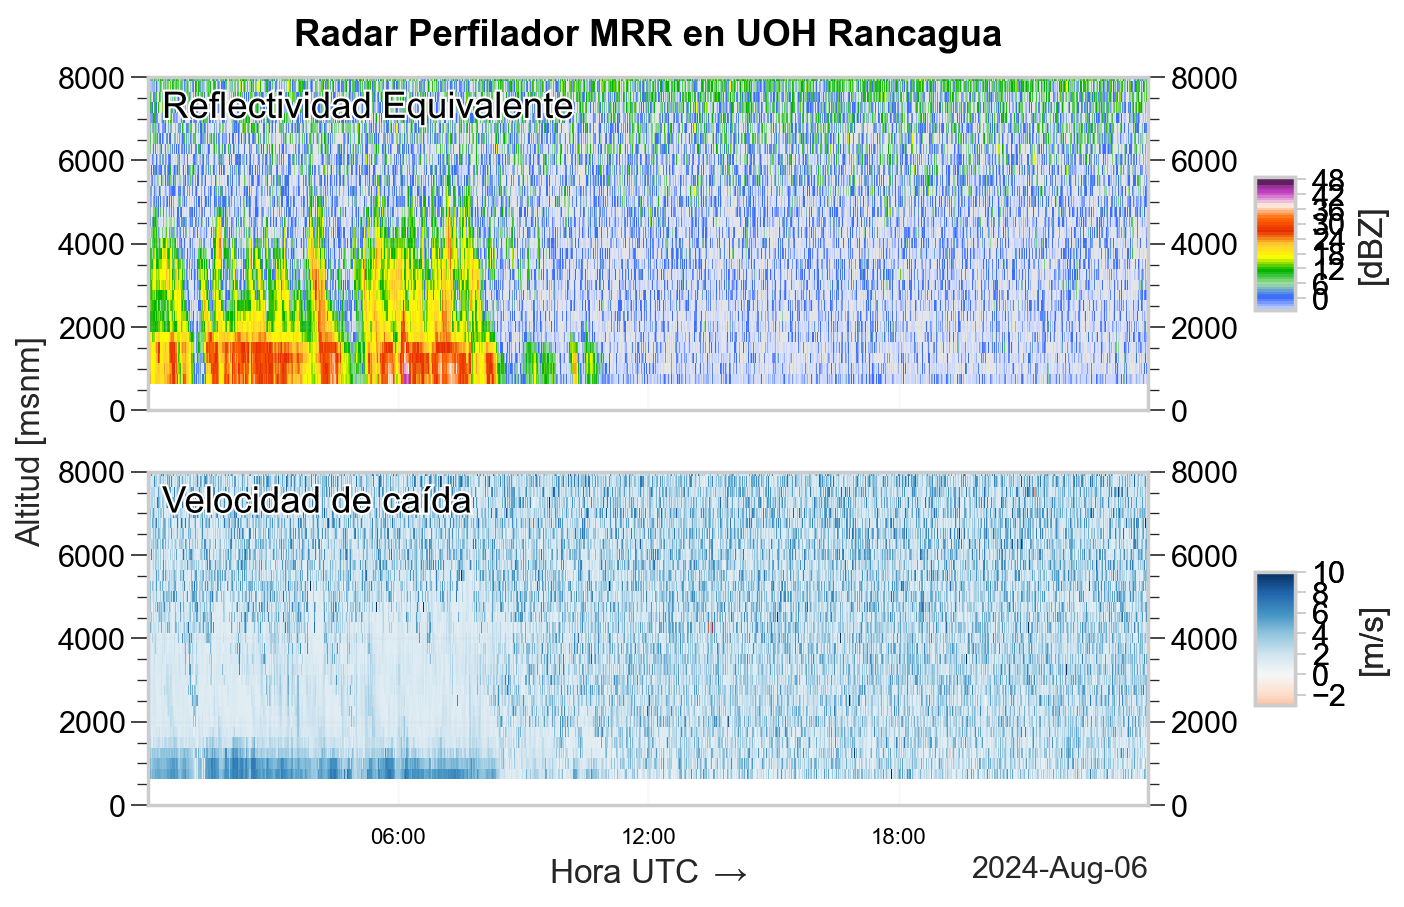

In [104]:
new_time = pd.to_datetime(ds.time.values)
xlim = [new_time[0], new_time[-1]]
heights = ds.height[0,:]+500
Ze = ds['attenuated_radar_reflectivity']
Vf = ds['fall_velocity']

plot_mrr2(xlim,pd.to_datetime(ds.time.values) , heights, Ze, Vf, hora_local=False)


Filtro para ruido

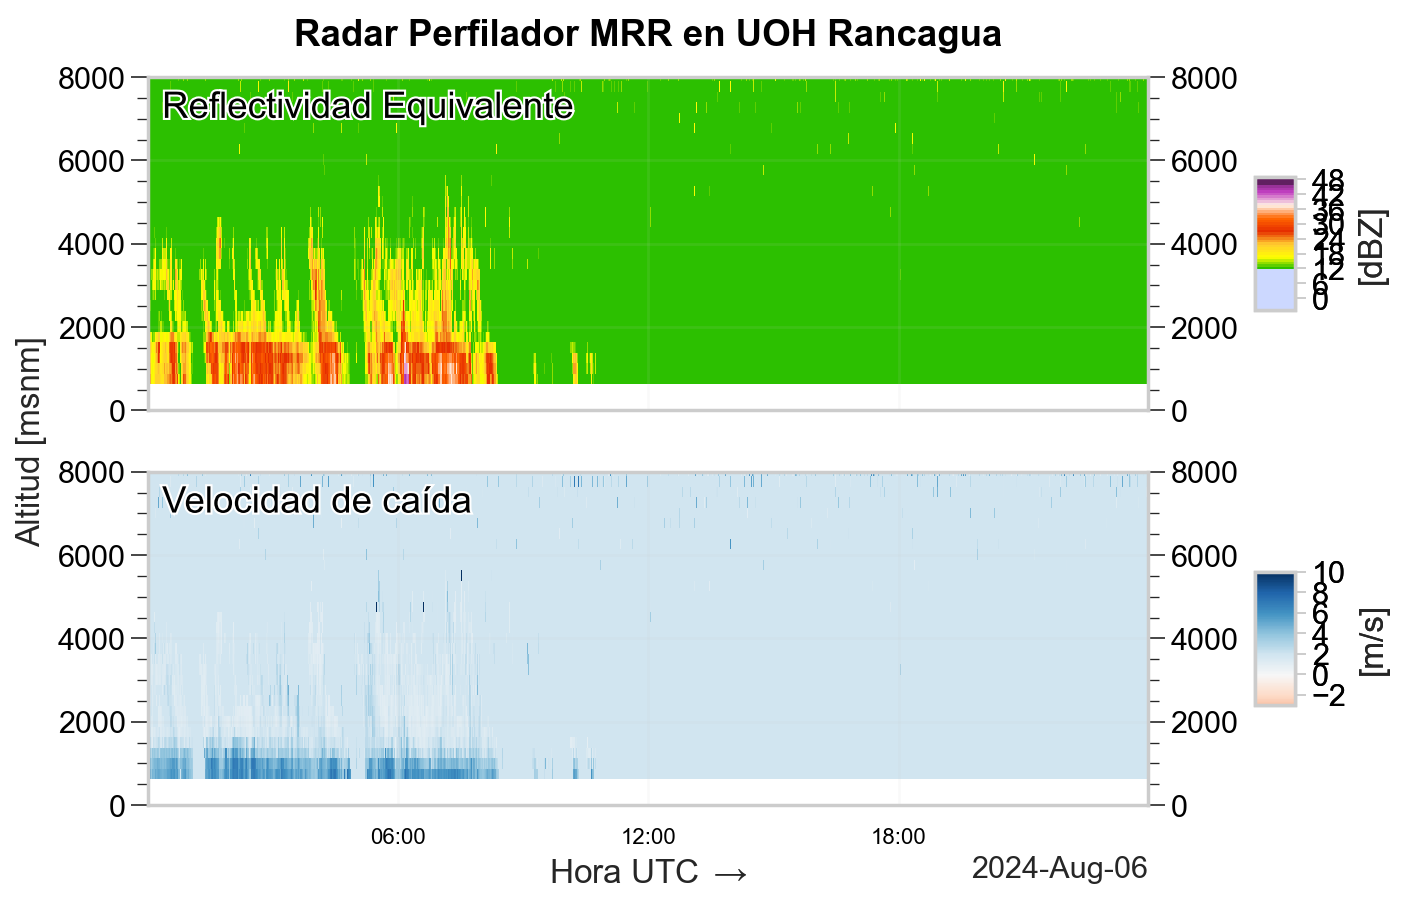

In [105]:
Ze_filtered, Vf_filtered = ruido(Ze, Vf)

plot_mrr2(xlim,pd.to_datetime(ds.time.values) , heights, Ze_filtered, Vf=Vf_filtered, hora_local=False)

Cálculo y ploteo del gradiente

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\173114761.py:109: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


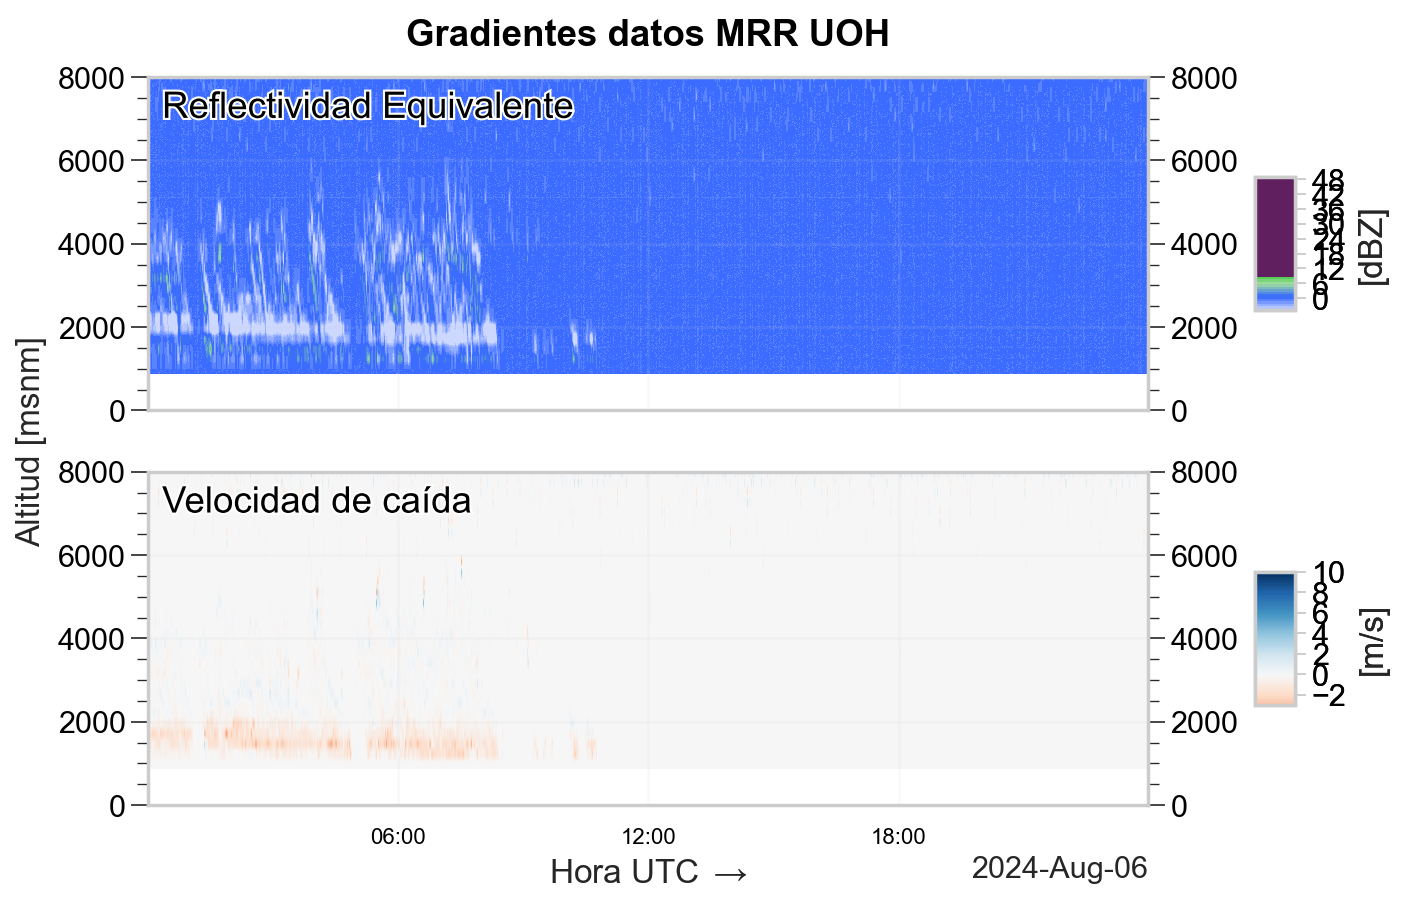

In [106]:
altura_inicial_desfase = 500 + (heights[1] - heights[0]) / 2   # Ajuste altura

heights_ajustado = ds.height[0, :] + altura_inicial_desfase

marco = 1
gradiente_Ze = calcular_gradiente(Ze_filtered.T, marco) #el problema, una vez más era la traspuesta
gradiente_Vf = calcular_gradiente(Vf_filtered.T, marco)
plot_mrr3_imshow(xlim, new_time, heights_ajustado, gradiente_Ze, Vf=gradiente_Vf, hora_local=False)

Isoterma cero detectada con gradiente base

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\3688920385.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


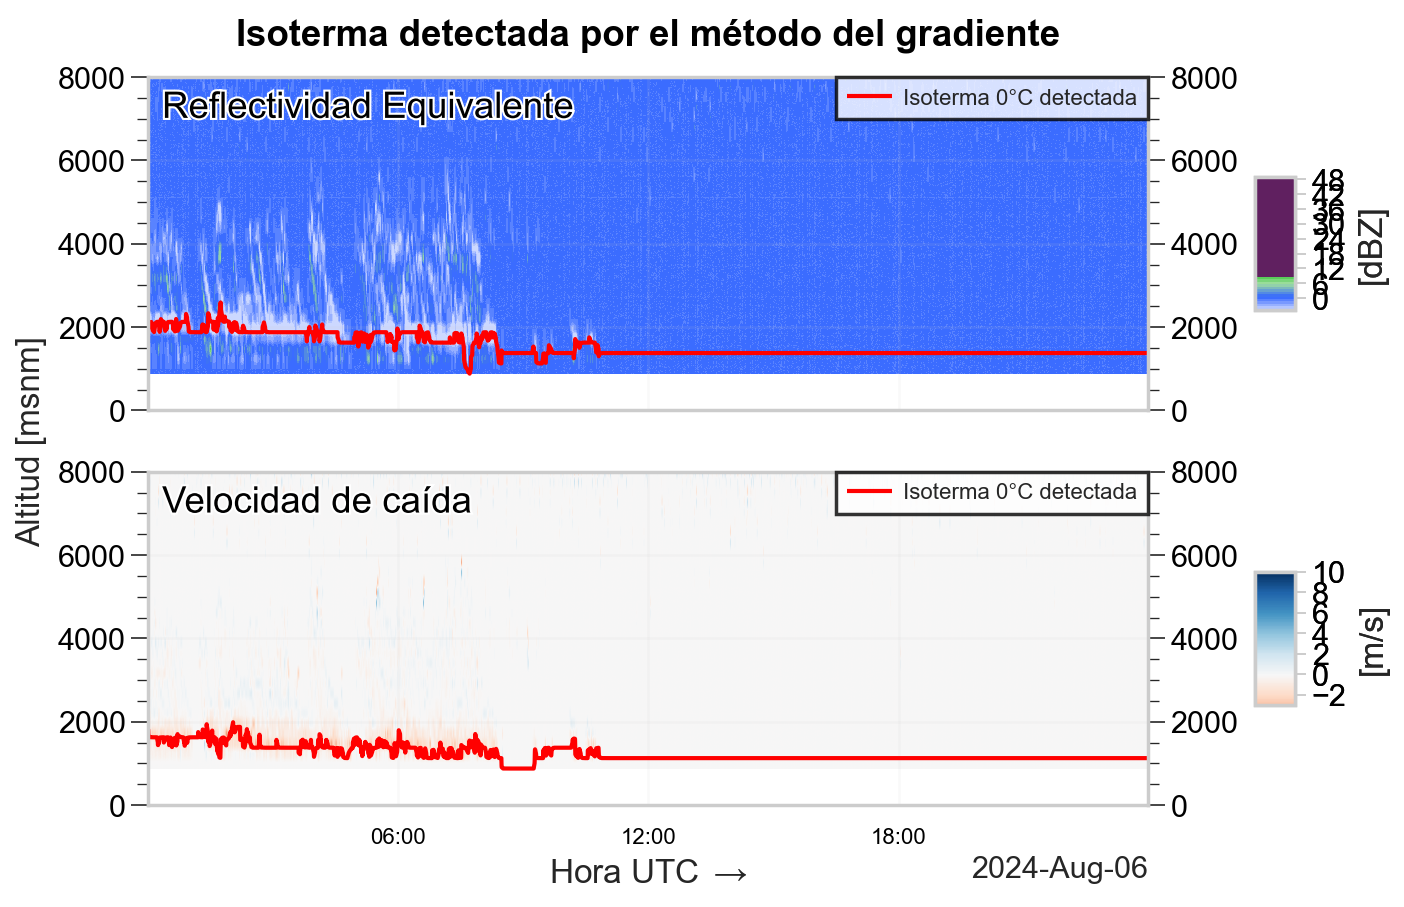

In [107]:
resultados_isoterma_Ze_NP = detectar_isoterma_cero(gradiente_Ze, altura_inicial=2000, heights_ajustado=heights_ajustado)
resultados_isoterma_Vf_NP = detectar_isoterma_cero(gradiente_Vf, altura_inicial=2000, heights_ajustado=heights_ajustado)

# Graficar con la isoterma
plot_mrr3_imshow_con_isoterma(xlim, new_time, heights_ajustado, gradiente_Ze, resultados_isoterma_Ze_NP, Vf=gradiente_Vf, isoterma_results_Vf=resultados_isoterma_Vf_NP)

Isoterma cero detectada con gradiente ponderado

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\3688920385.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


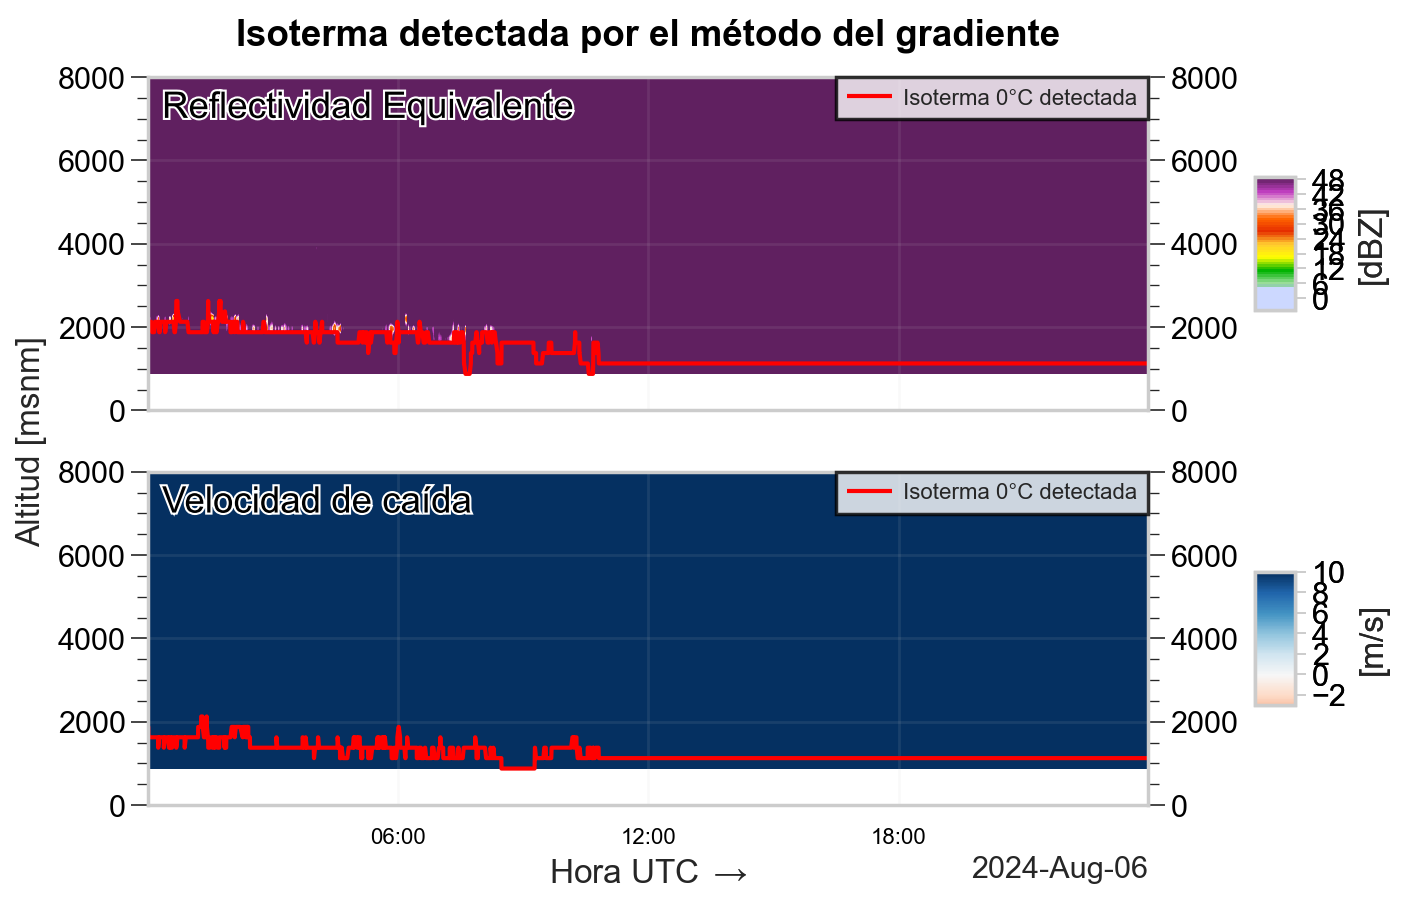

In [108]:
resultados_isoterma_Ze, gradiente_pond_Ze = detectar_isoterma_cero_ponderado(gradiente_Ze, altura_inicial=2000, heights_ajustado=heights_ajustado)
resultados_isoterma_Vf, gradiente_pond_Vf = detectar_isoterma_cero_ponderado(gradiente_Vf, altura_inicial=2000, heights_ajustado=heights_ajustado)

plot_mrr3_imshow_con_isoterma(xlim, new_time, heights_ajustado, gradiente_pond_Ze.T, resultados_isoterma_Ze, Vf=gradiente_pond_Vf.T, isoterma_results_Vf=resultados_isoterma_Vf)

##### Aplicación filtro de Kalman para la reflectividad

Reajuste variables

In [109]:
IndicesIsoterma=[]
for resultado in resultados_isoterma_Ze:
    t = resultado["iter"]
    altura_minima = resultado["altura_minima"]
    idx_altura = int((np.abs(heights_ajustado - altura_minima)).argmin())
    IndicesIsoterma.append(idx_altura)

FactorConversion = (heights[-1].values-500)/ len(heights)
AlturasIsoterma = np.array(IndicesIsoterma) * FactorConversion

#(NOTA: Se está usando la aproximación de la isoterma con gradiente ponderado en el filtro de Kalman!)

Llamada filtro de Kalman para la reflectividad

In [110]:
altura_inicial_desfase = 500 + (heights[1].values - heights[0].values) / 2
AlturasIsoterma_ajustadas = AlturasIsoterma + altura_inicial_desfase
delta_t = 20
Q_ruido_proceso_reflectividad = 10   # Ruido del proceso para reflectividad, aumentar
Q_ruido_proceso_gradiente = 0.05       # Ruido del proceso para gradiente
R_ruido_medicion = 5000                # Ruido de medición - Error de +- 70.71 m (sd raiz de 5000)

alturas_filtradas, ganancias, var_altura, var_velocidad, covar, tasa_cambio, gradientes_ponderados = filtro_kalman(AlturasIsoterma_ajustadas, gradiente_Ze,
                                   delta_t, 
                                   Q_ruido_proceso_reflectividad, 
                                   Q_ruido_proceso_gradiente, 
                                   R_ruido_medicion, 
                                   heights_ajustado)

Visualización diferencia entre aproximación por método del gradiente y filtro de Kalman (reflectividad)

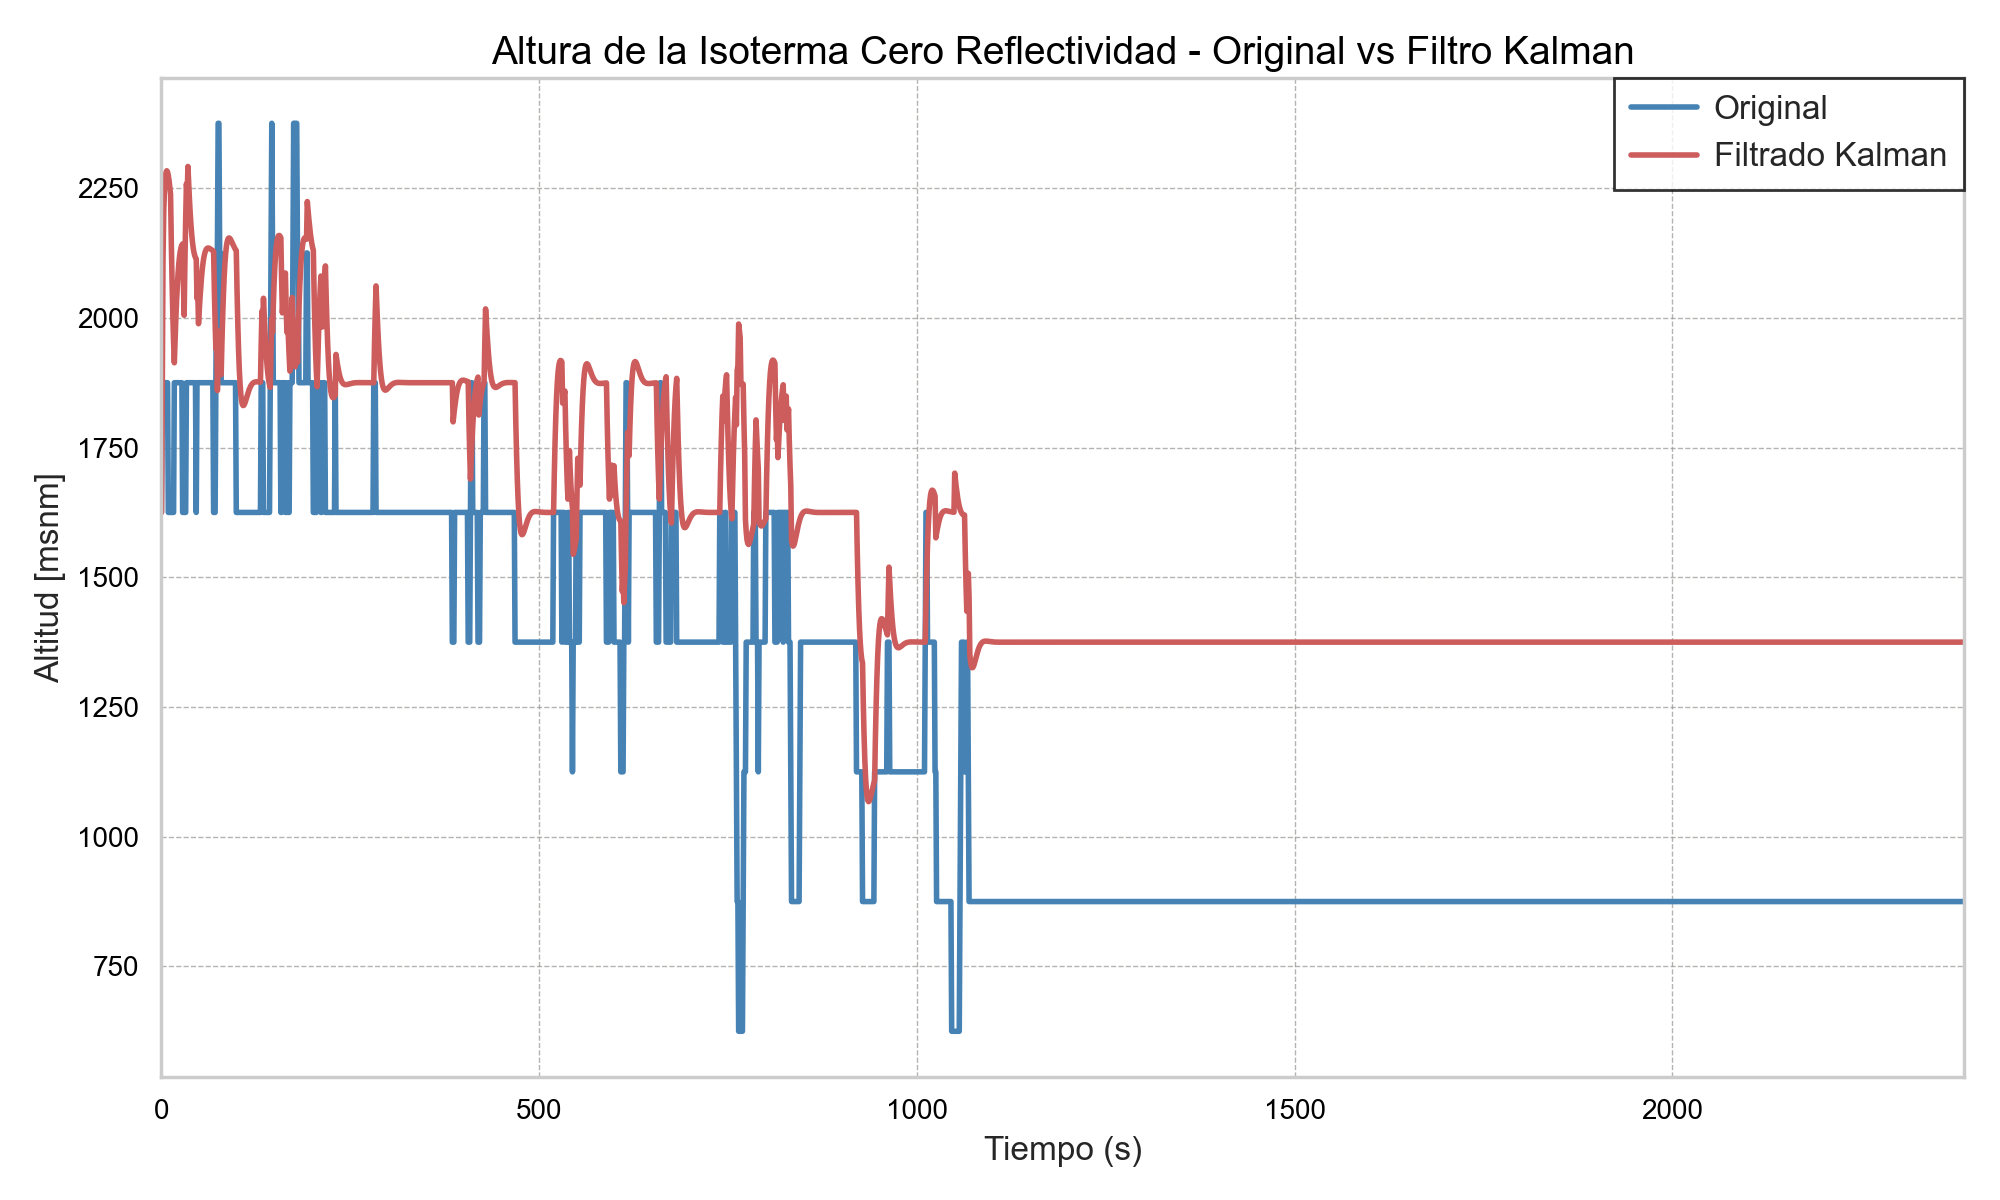

In [111]:
fig, ax = plt.subplots(figsize=(10, 6))  
ax.plot(AlturasIsoterma_ajustadas, label="Original", linestyle='-', color='steelblue', linewidth=2)
ax.plot(alturas_filtradas, label="Filtrado Kalman", linestyle='-', color='indianred', linewidth=2)
ax.set_xlabel('Tiempo (s)', fontsize=12) 
ax.set_ylabel('Altitud [msnm]', fontsize=12)
ax.set_title('Altura de la Isoterma Cero Reflectividad - Original vs Filtro Kalman', fontsize=14)
ax.set_xlim([0, len(AlturasIsoterma)])     
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.tight_layout()  
plt.show()

Visualización tasa de cambio del filtro (reflectividad)

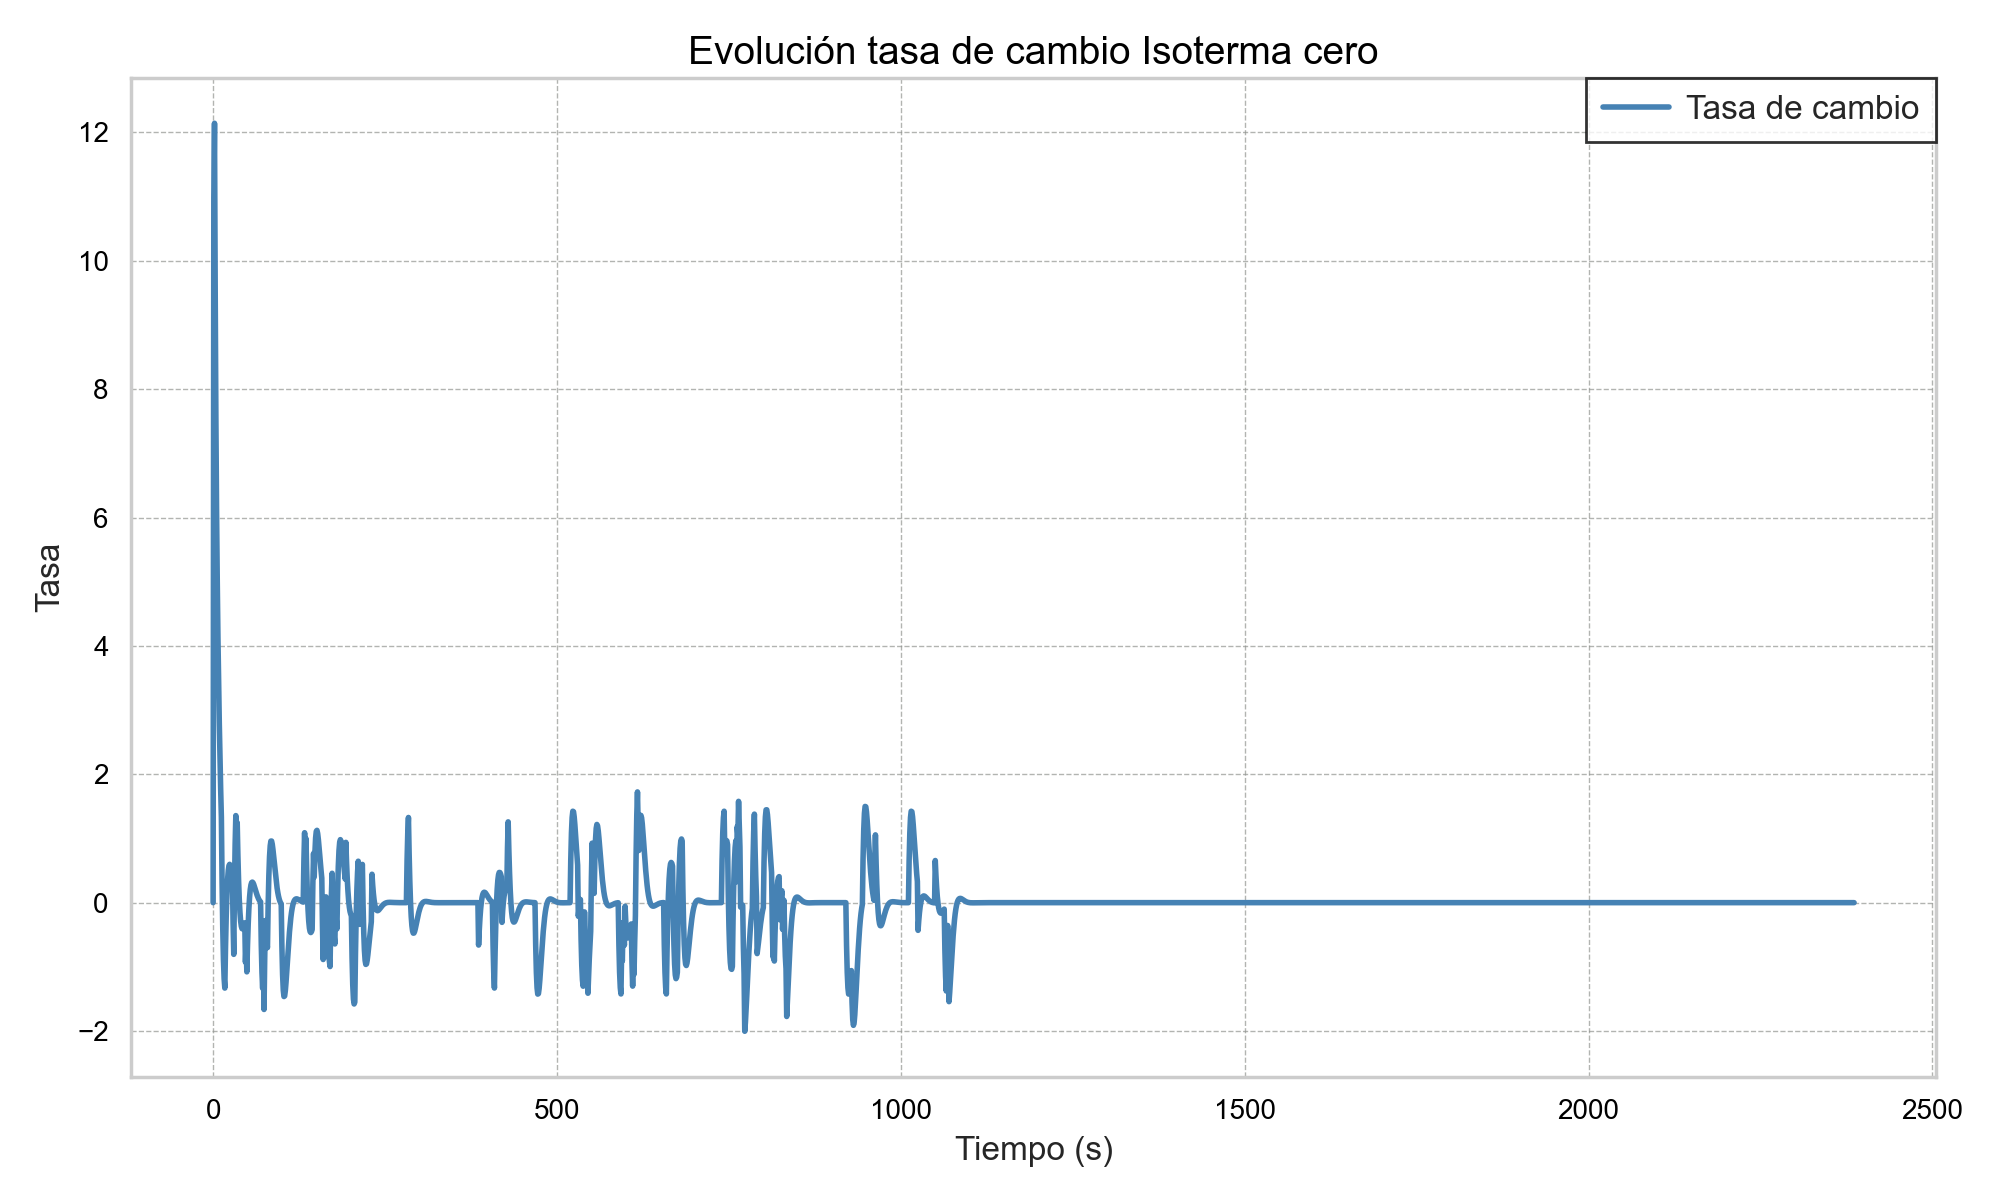

In [112]:
fig, ax = plt.subplots(figsize=(10, 6))  
ax.plot(tasa_cambio, label="Tasa de cambio", color='steelblue', linewidth=2)
ax.set_xlabel('Tiempo (s)', fontsize=12) 
ax.set_ylabel('Tasa', fontsize=12)
ax.set_title('Evolución tasa de cambio Isoterma cero', fontsize=14) 
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.tight_layout()  
plt.show()

Visualización cercana de isoterma cero e intervalo de confianza detectado por el filtro de Kalman (reflectividad)

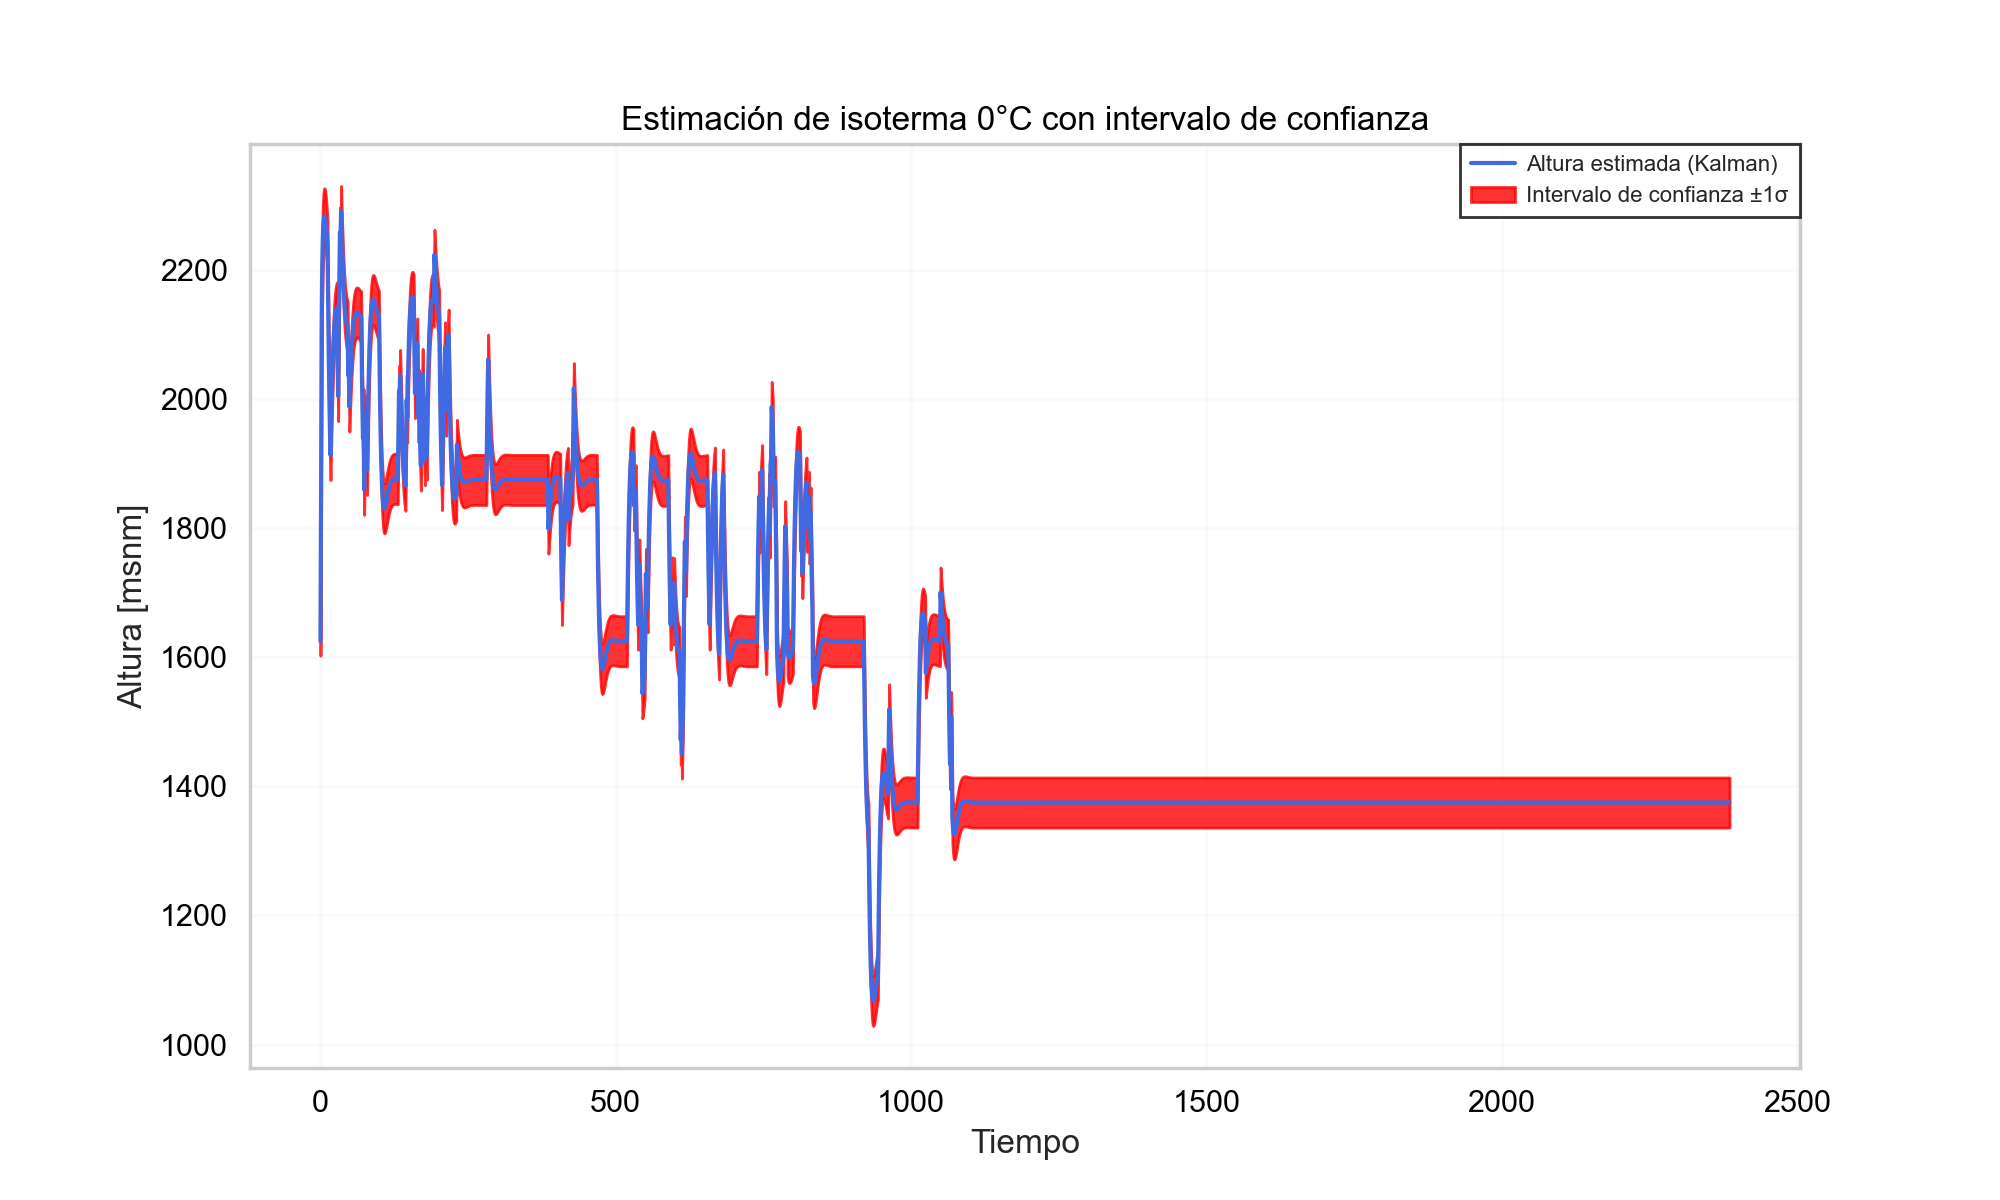

In [113]:
covarianzas = np.array(var_altura)
desviacion_std = np.sqrt(covarianzas)

#Intervalos de confianza
superior = alturas_filtradas + desviacion_std
inferior = alturas_filtradas - desviacion_std

#Plot
plt.figure(figsize=(10,6))
plt.plot(alturas_filtradas, label='Altura estimada (Kalman)', color='royalblue')
plt.fill_between(range(len(alturas_filtradas)), inferior, superior, color='red', alpha=0.8,
                 label='Intervalo de confianza ±1σ')
plt.xlabel('Tiempo')
plt.ylabel('Altura [msnm]')
plt.title('Estimación de isoterma 0°C con intervalo de confianza')
plt.legend()
plt.grid(True)
plt.show()

##### Aplicación filtro de Kalman para la velocidad de caída

Reajuste variables

In [114]:
IndicesIsoterma_Vf=[]
for resultado in resultados_isoterma_Vf:
    t = resultado["iter"]
    altura_minima = resultado["altura_minima"]
    idx_altura = int((np.abs(heights_ajustado - altura_minima)).argmin())
    IndicesIsoterma_Vf.append(idx_altura)

AlturasIsoterma_Vf = np.array(IndicesIsoterma_Vf) * FactorConversion

Llamada filtro de Kalman para la velocidad de caída

In [115]:
AlturasIsoterma_ajustadas_Vf = AlturasIsoterma_Vf + altura_inicial_desfase
delta_t = 20
Q_ruido_proceso_reflectividad = 10   # Ruido del proceso para reflectividad
Q_ruido_proceso_gradiente = 0.05       # Ruido del proceso para gradiente
R_ruido_medicion = 5000                   # Ruido de medición
factor_ponderador = 0.65

alturas_filtradas_Vf, ganancias_Vf, var_altura_Vf, var_velocidad_Vf, covar_Vf, tasa_cambio_Vf, gradiente_ponderado_Vf = filtro_kalman(AlturasIsoterma_ajustadas_Vf, gradiente_Vf,
                                   delta_t, 
                                   Q_ruido_proceso_reflectividad, 
                                   Q_ruido_proceso_gradiente, 
                                   R_ruido_medicion, 
                                   heights_ajustado)

Visualización diferencia entre aproximación por método del gradiente y filtro de Kalman (velocidad de caída)

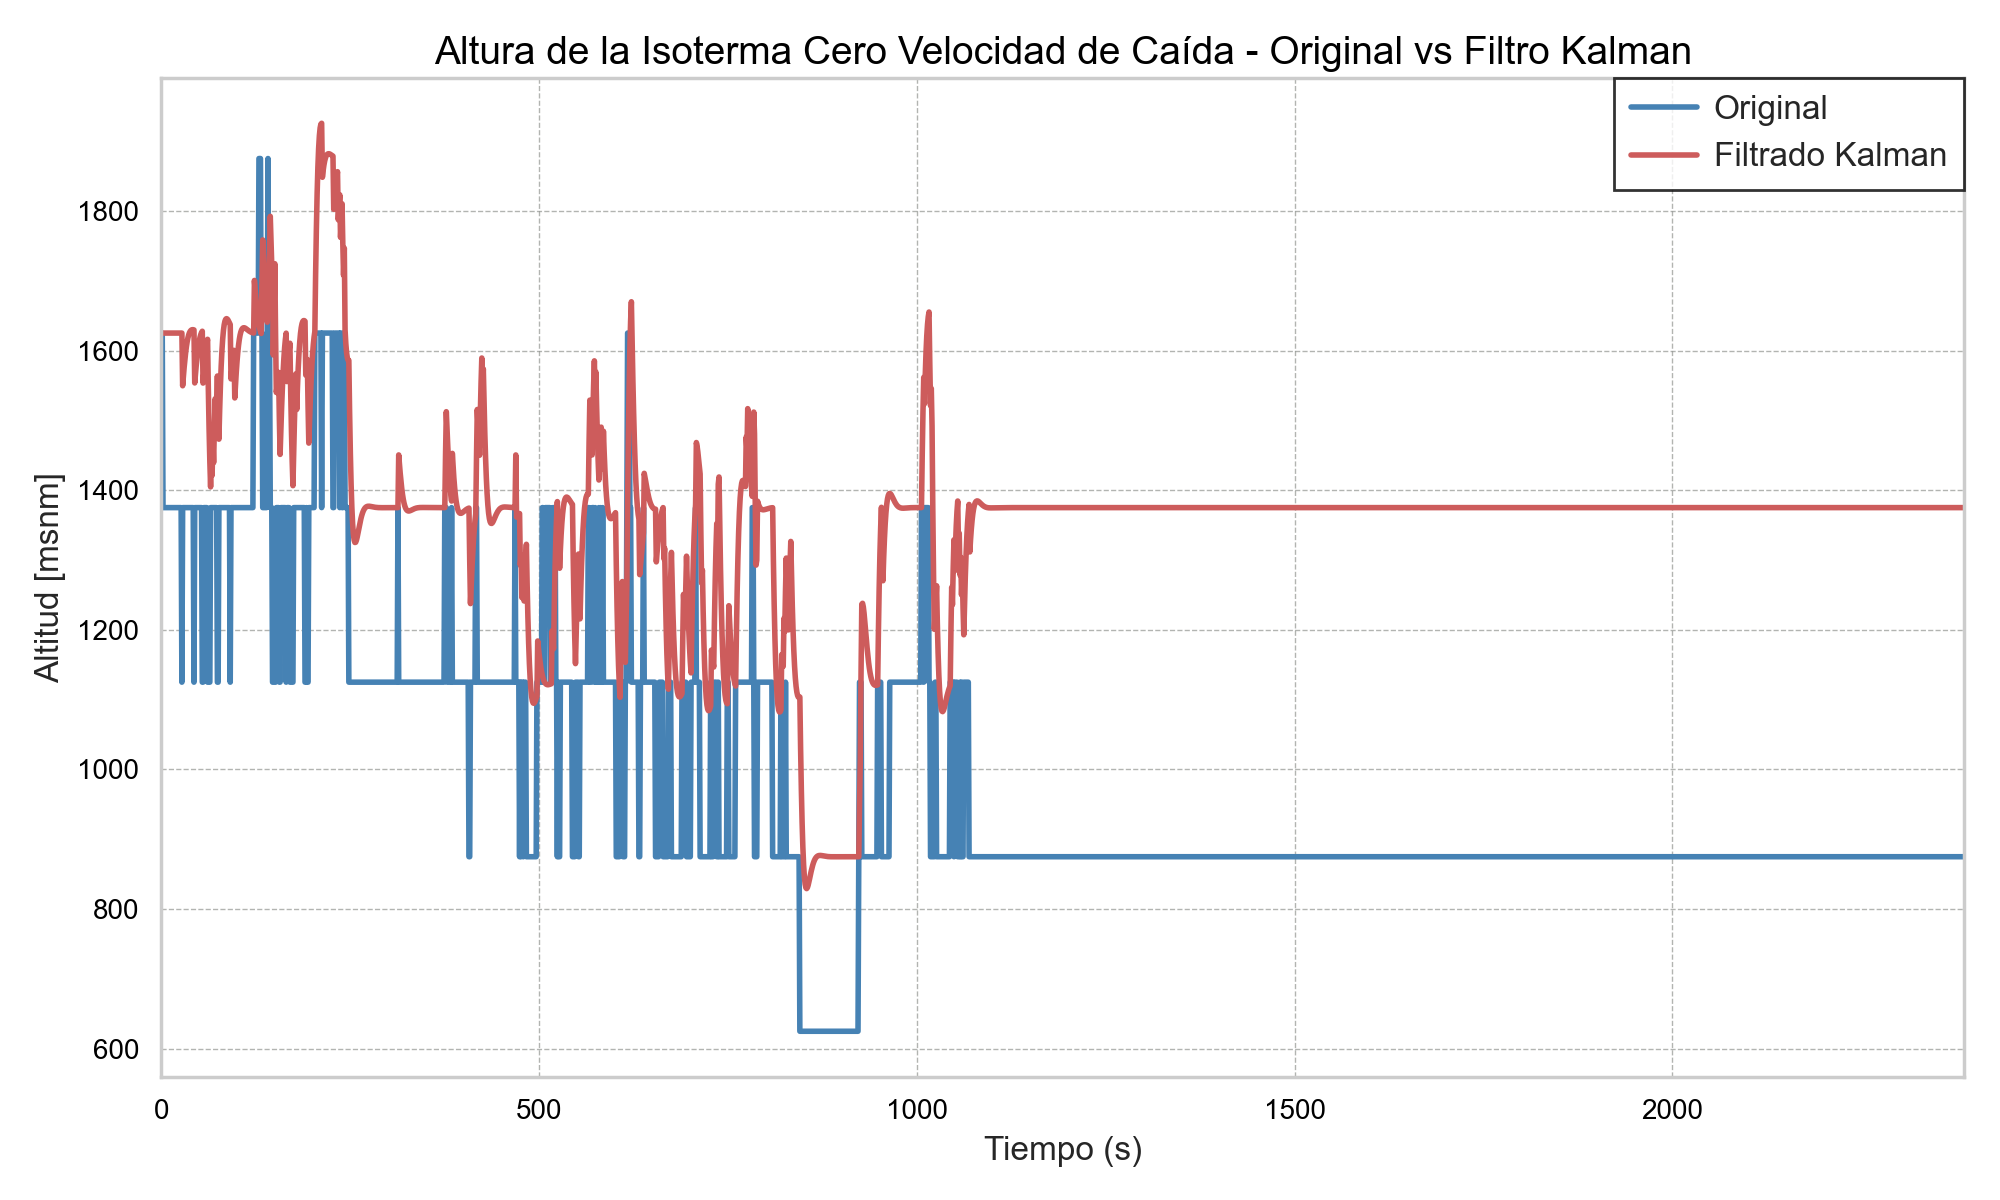

In [116]:
fig, ax = plt.subplots(figsize=(10, 6))  
ax.plot(AlturasIsoterma_ajustadas_Vf, label="Original", linestyle='-', color='steelblue', linewidth=2)
ax.plot(alturas_filtradas_Vf, label="Filtrado Kalman", linestyle='-', color='indianred', linewidth=2)
ax.set_xlabel('Tiempo (s)', fontsize=12) 
ax.set_ylabel('Altitud [msnm]', fontsize=12)
ax.set_title('Altura de la Isoterma Cero Velocidad de Caída - Original vs Filtro Kalman', fontsize=14)
ax.set_xlim([0, len(AlturasIsoterma)])  
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.tight_layout()  
plt.show()

Visualización tasa de cambio del filtro (velocidad de caída)

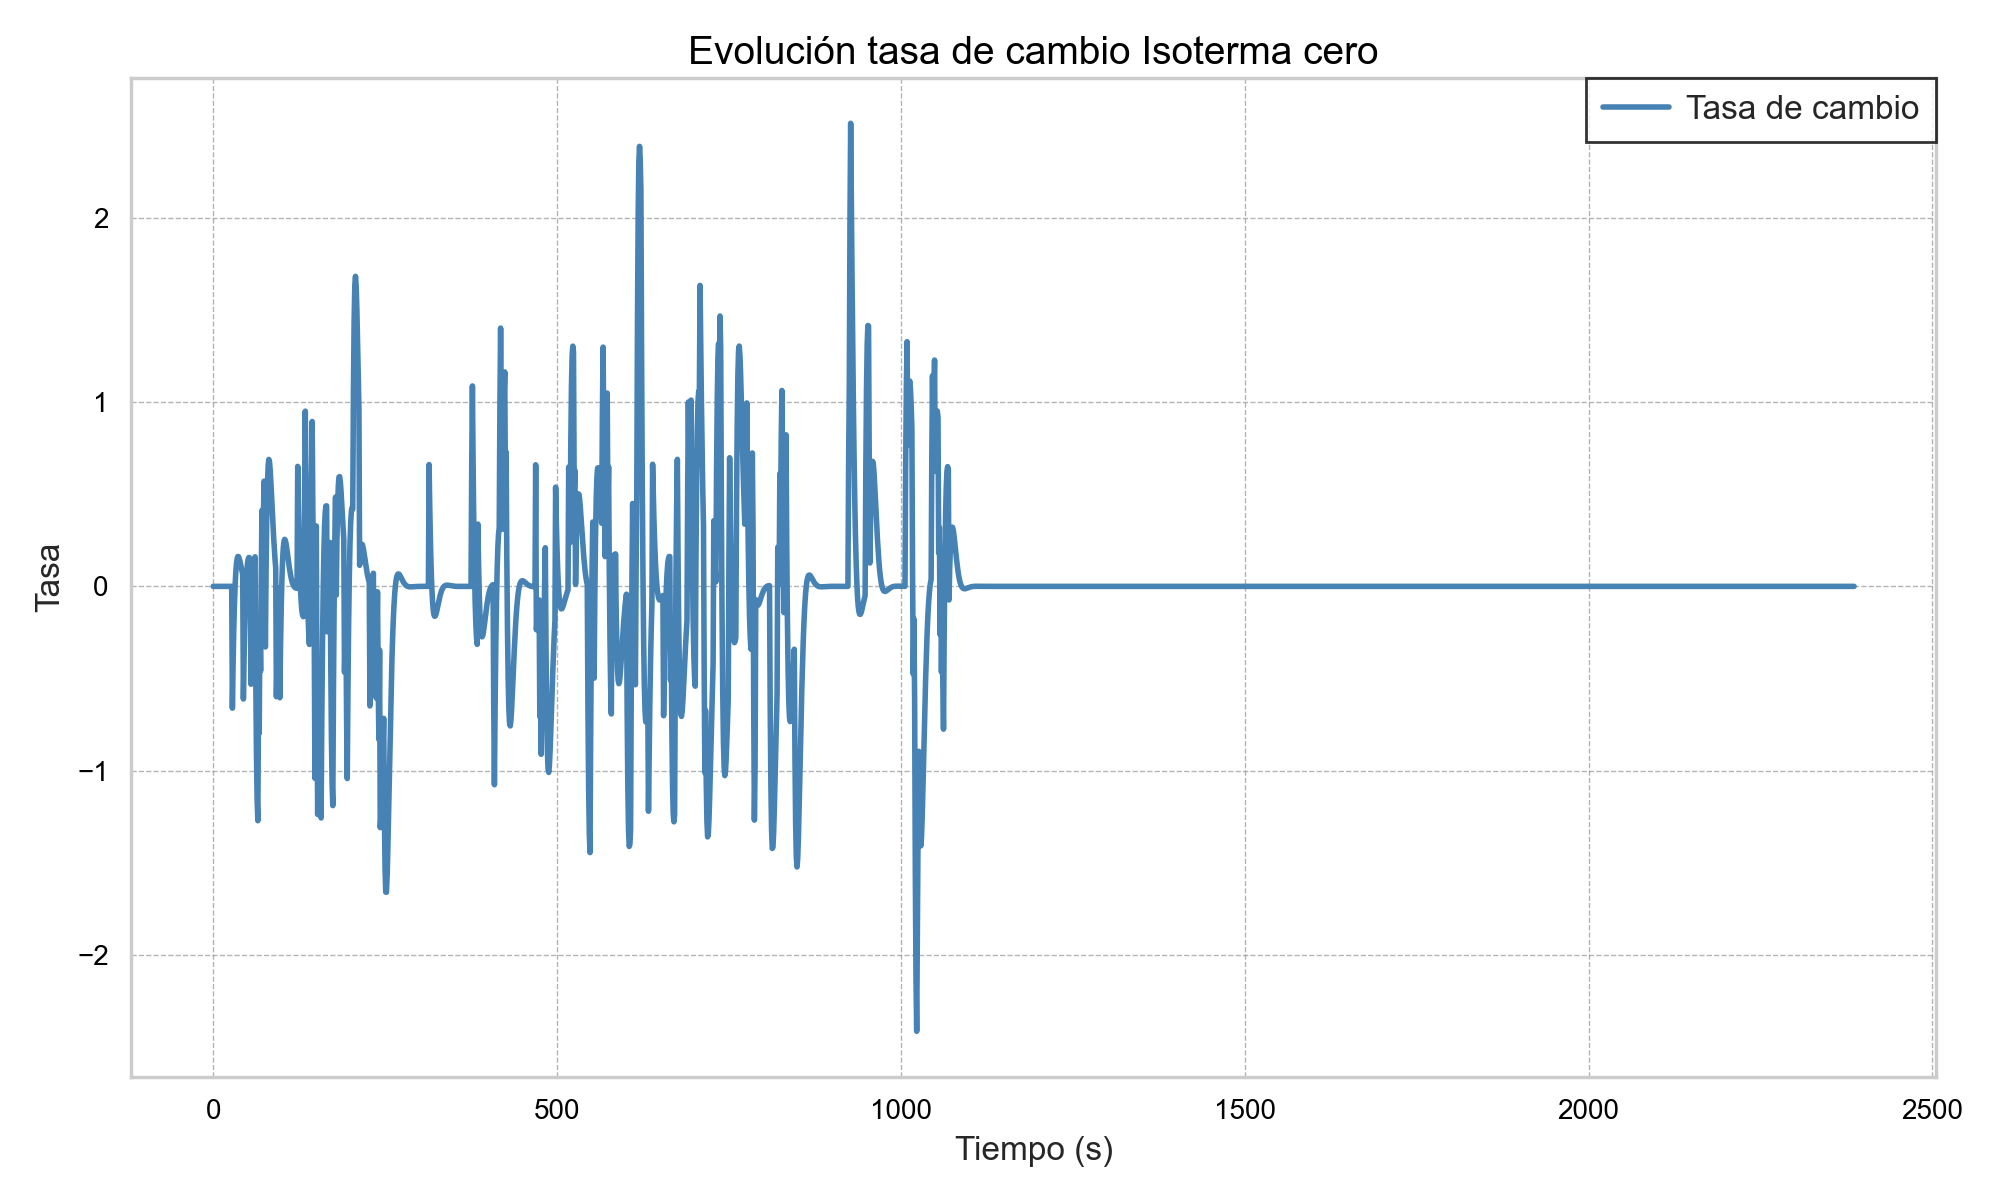

In [117]:
fig, ax = plt.subplots(figsize=(10, 6))  
ax.plot(tasa_cambio_Vf, label="Tasa de cambio", color='steelblue', linewidth=2)
ax.set_xlabel('Tiempo (s)', fontsize=12) 
ax.set_ylabel('Tasa', fontsize=12)
ax.set_title('Evolución tasa de cambio Isoterma cero', fontsize=14) 
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.tight_layout()  
plt.show()

Visualización cercana de isoterma cero e intervalo de confianza detectado por el filtro de Kalman (velocidad de caída)

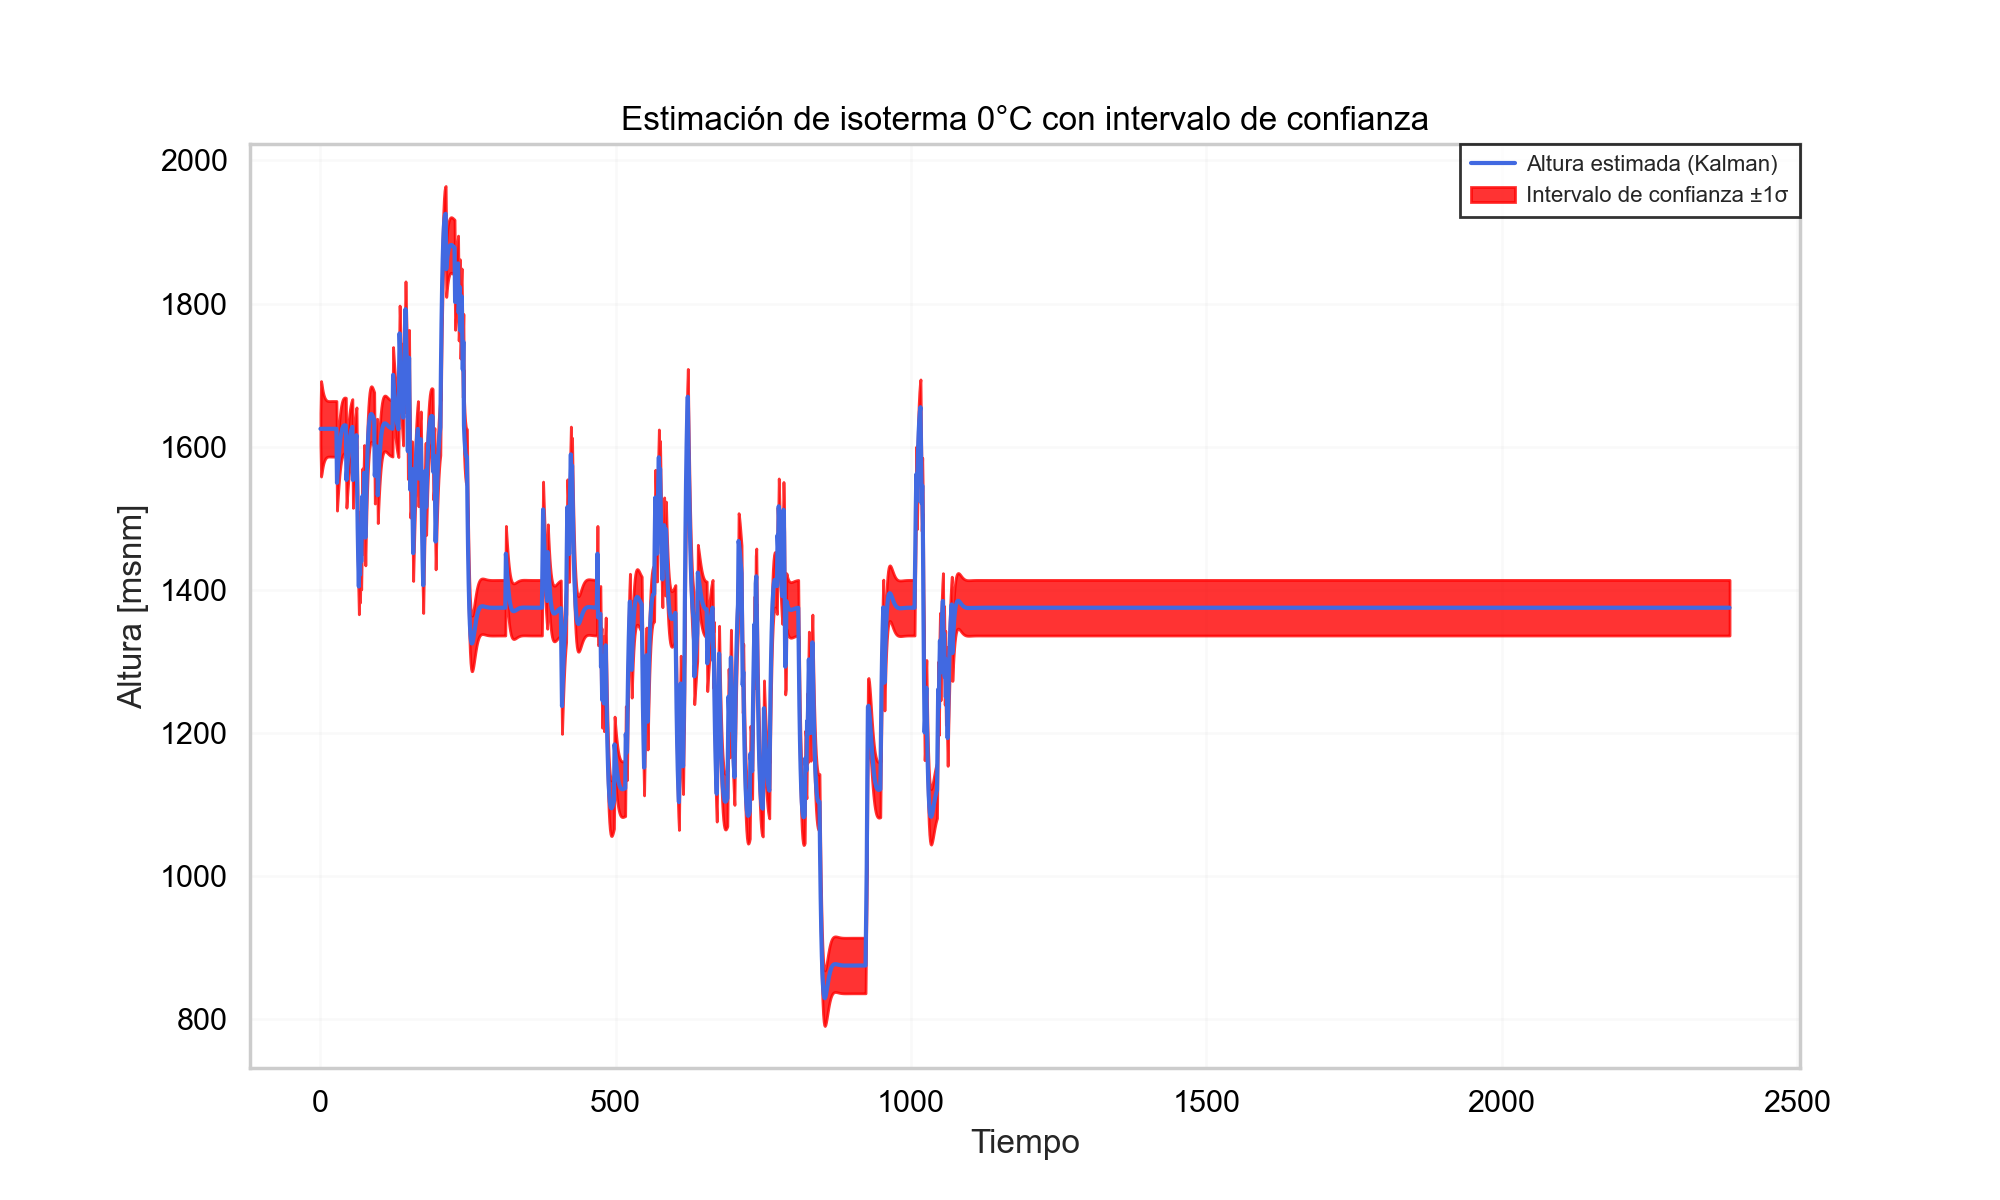

In [118]:
covarianzas_Vf = np.array(var_altura_Vf)
desviacion_std_Vf = np.sqrt(covarianzas_Vf)

# Intervalos de confianza
superior_Vf = alturas_filtradas_Vf + desviacion_std_Vf
inferior_Vf = alturas_filtradas_Vf - desviacion_std_Vf

# Plot
plt.figure(figsize=(10,6))
plt.plot(alturas_filtradas_Vf, label='Altura estimada (Kalman)', color='royalblue')
plt.fill_between(range(len(alturas_filtradas_Vf)), inferior_Vf, superior_Vf, color='red', alpha=0.8,
                 label='Intervalo de confianza ±1σ')
plt.xlabel('Tiempo')
plt.ylabel('Altura [msnm]')
plt.title('Estimación de isoterma 0°C con intervalo de confianza')
plt.legend()
plt.grid(True)
plt.show()

##### Plot final

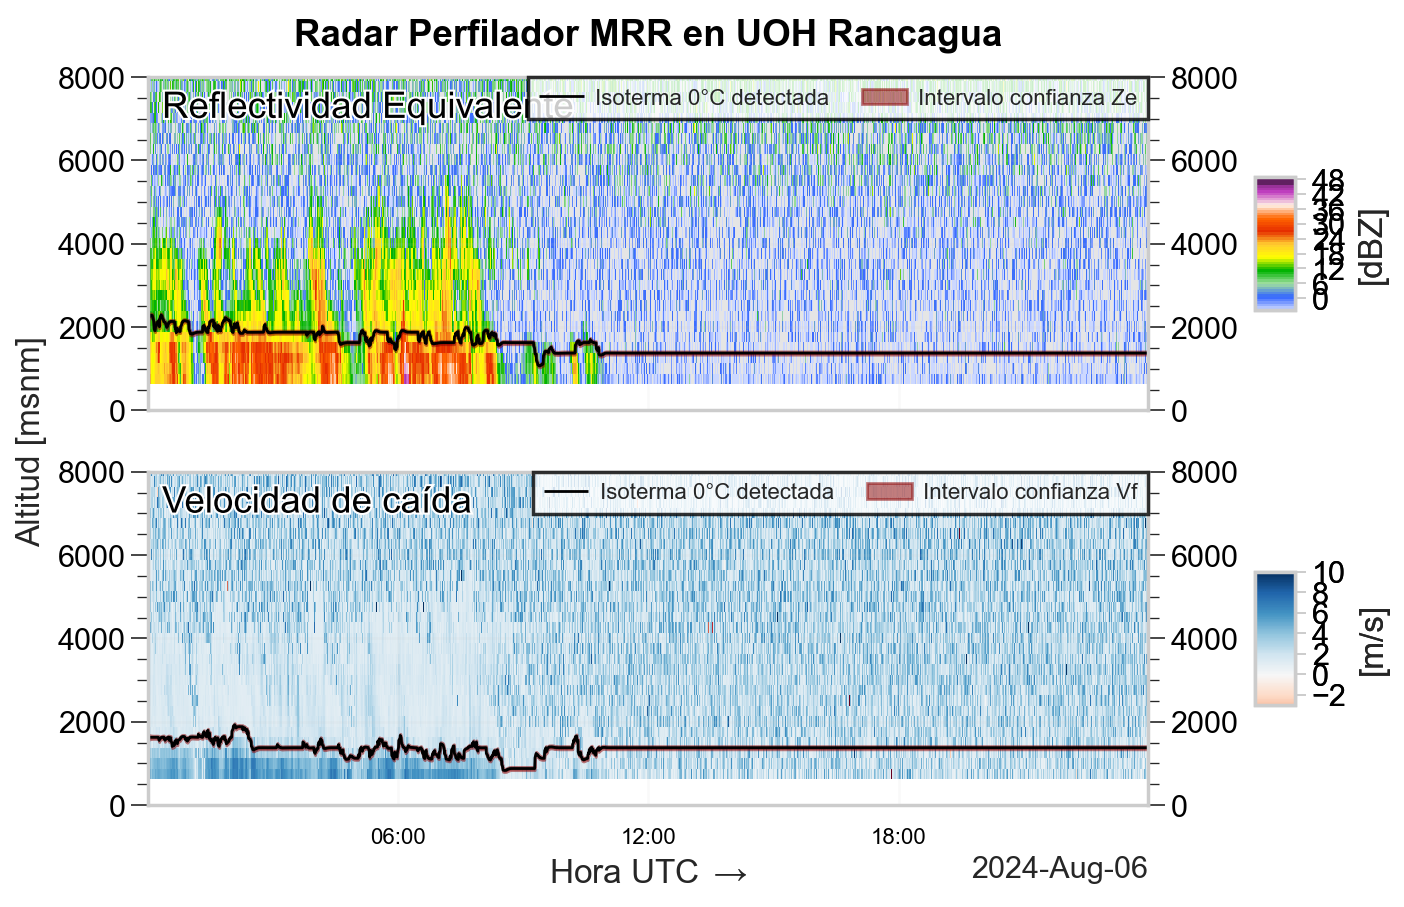

In [119]:
# Grafico solo de reflectividad
new_time = pd.to_datetime(ds.time.values)
xlim = [new_time[0], new_time[-1]]
heights = ds.height[0, :].values + 500  
Ze = ds['attenuated_radar_reflectivity'].T 

N = len(new_time)
alturas_filtradas = ajustar_largo(alturas_filtradas, N)
superior = ajustar_largo(superior, N)
inferior = ajustar_largo(inferior, N)

alturas_filtradas_Vf = ajustar_largo(alturas_filtradas_Vf, N)
superior_Vf = ajustar_largo(superior_Vf, N)
inferior_Vf = ajustar_largo(inferior_Vf, N)


plot_mrr_Isotermas4(
    xlim=xlim,
    times=new_time,
    heights=heights,
    Ze=Ze.T,
    isoterma_Ze=alturas_filtradas,  # Línea de isoterma filtrada
    Vf=Vf,
    isoterma_Vf=alturas_filtradas_Vf,
    hora_local=False,
    sd_sup_Ze=superior,
    sd_inf_Ze=inferior,
    sd_sup_Vf=superior_Vf,
    sd_inf_Vf=inferior_Vf
)

## Datos base: Día 21/05/2024

##### Pasos previos

Ploteo inicial

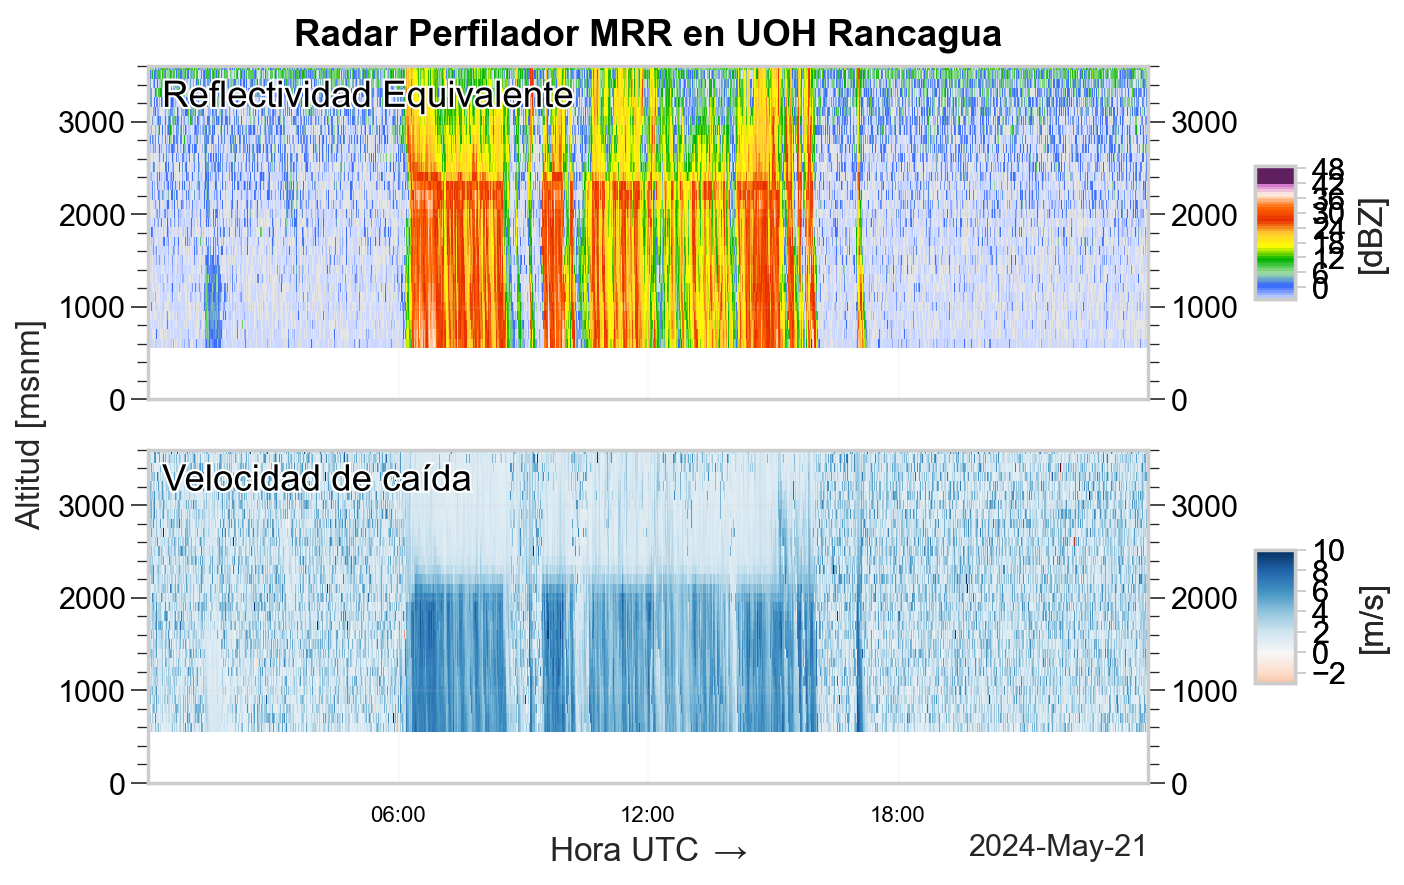

In [120]:
new_time_0521 = pd.to_datetime(ds_0521.time.values)
xlim_0521 = [new_time_0521[0], new_time_0521[-1]]
heights_0521 = ds_0521.height[0,:]+500
Ze_0521 = ds_0521['attenuated_radar_reflectivity']
Vf_0521 = ds_0521['fall_velocity']

plot_mrr2(xlim_0521,pd.to_datetime(ds_0521.time.values) , heights_0521, Ze_0521, Vf_0521, hora_local=False)

Filtro para ruido

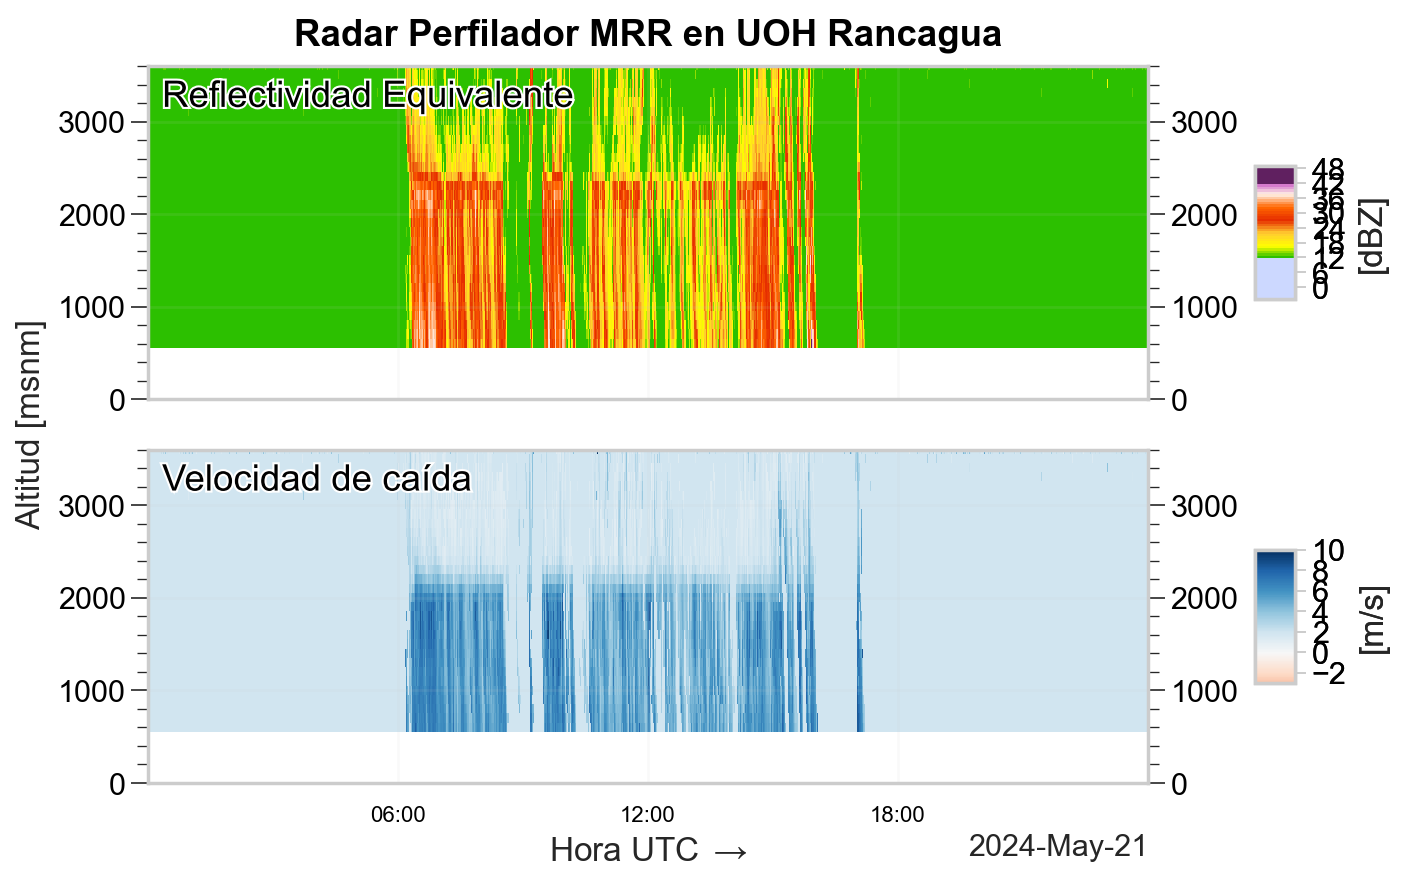

In [121]:
Ze_filtered_0521, Vf_filtered_0521 = ruido(Ze_0521, Vf_0521)

plot_mrr2(xlim_0521,pd.to_datetime(ds_0521.time.values) , heights_0521, Ze_filtered_0521, Vf=Vf_filtered_0521, hora_local=False)

Cálculo y ploteo del gradiente

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\173114761.py:109: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


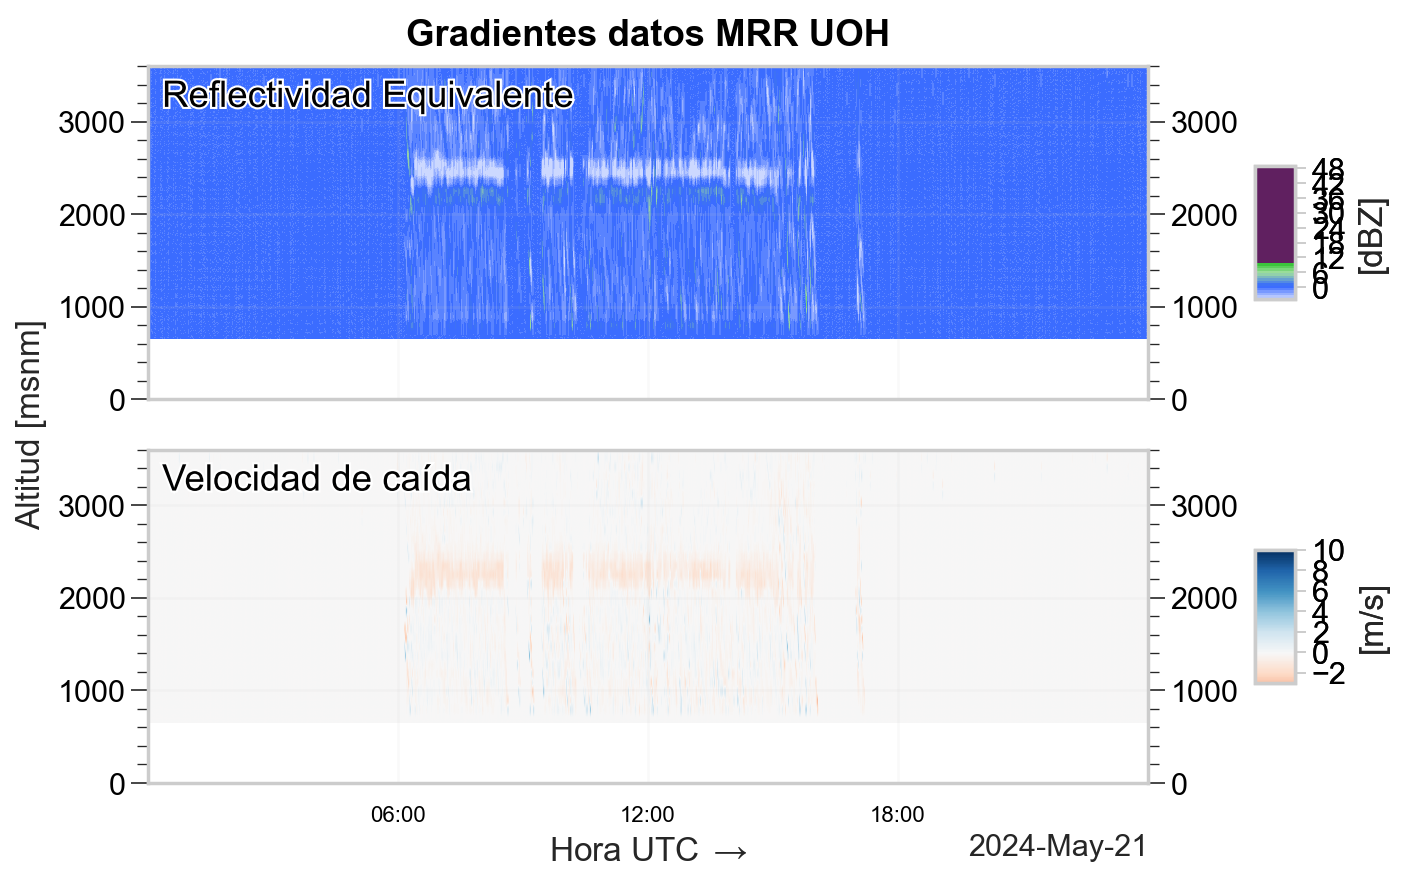

In [122]:
altura_inicial_desfase_0521 = 500 + (heights_0521[1] - heights_0521[0]) / 2   # Ajuste altura

heights_ajustado_0521 = ds_0521.height[0, :] + altura_inicial_desfase_0521

marco = 1
gradiente_Ze_0521 = calcular_gradiente(Ze_filtered_0521.T, marco)
gradiente_Vf_0521 = calcular_gradiente(Vf_filtered_0521.T, marco)
plot_mrr3_imshow(xlim_0521, new_time_0521, heights_ajustado_0521, gradiente_Ze_0521, Vf=gradiente_Vf_0521, hora_local=False)

Isoterma cero detectada con gradiente base

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\3688920385.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


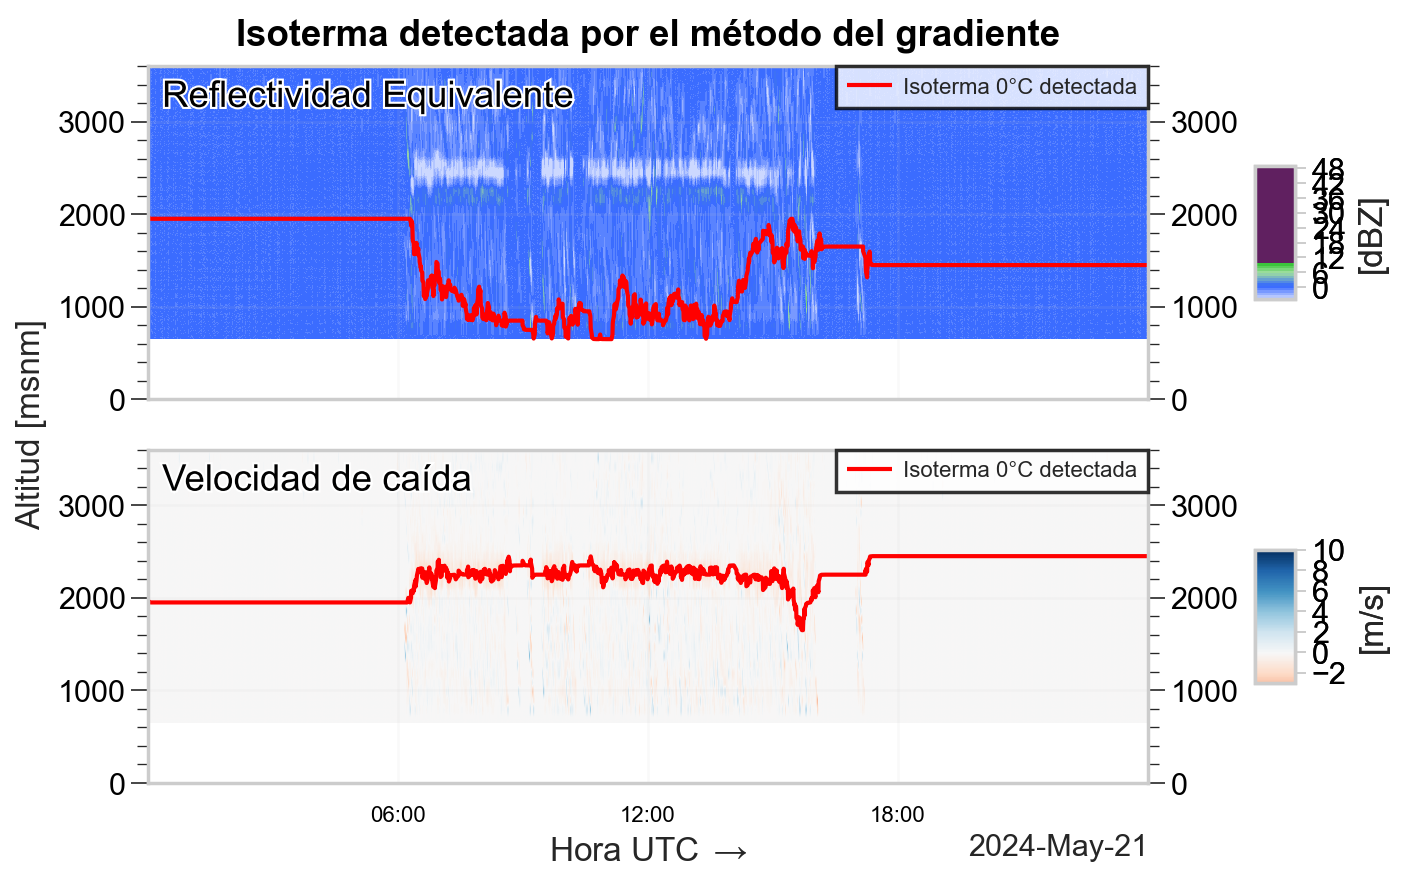

In [123]:
resultados_isoterma_Ze_NP_0521 = detectar_isoterma_cero(gradiente_Ze_0521, altura_inicial=2000, heights_ajustado=heights_ajustado_0521)
resultados_isoterma_Vf_NP_0521 = detectar_isoterma_cero(gradiente_Vf_0521, altura_inicial=2000, heights_ajustado=heights_ajustado_0521)

# Graficar con la isoterma
plot_mrr3_imshow_con_isoterma(xlim_0521, new_time_0521, heights_ajustado_0521, gradiente_Ze_0521, resultados_isoterma_Ze_NP_0521, Vf=gradiente_Vf_0521, isoterma_results_Vf=resultados_isoterma_Vf_NP_0521)

Isoterma cero detectada con gradiente ponderado

C:\Users\conyl\AppData\Local\Temp\ipykernel_20244\3688920385.py:128: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


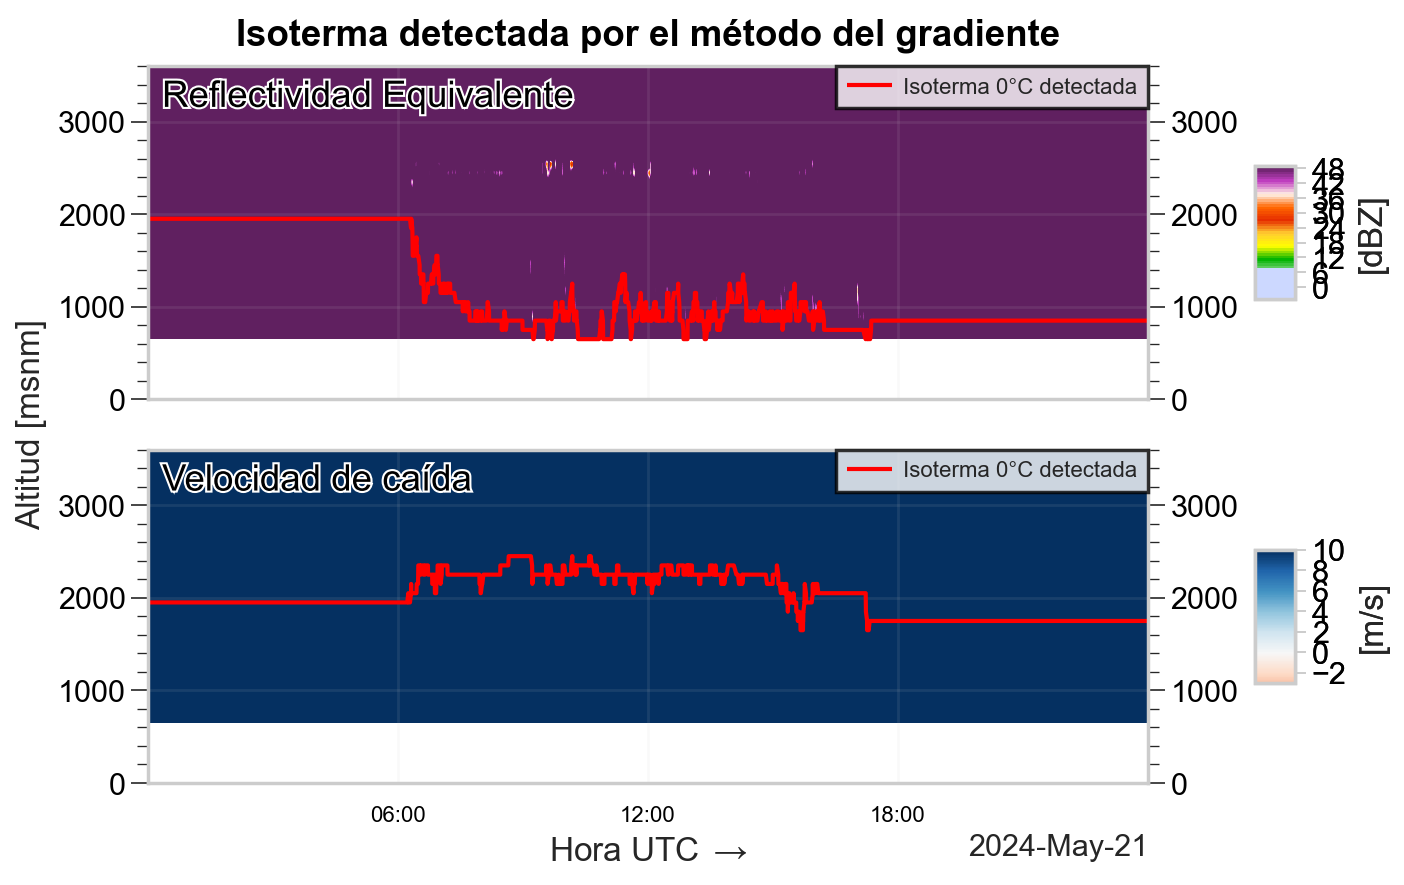

In [124]:
resultados_isoterma_Ze_0521, gradiente_pond_Ze_0521 = detectar_isoterma_cero_ponderado(gradiente_Ze_0521, altura_inicial=2000, heights_ajustado=heights_ajustado_0521)
resultados_isoterma_Vf_0521, gradiente_pond_Vf_0521 = detectar_isoterma_cero_ponderado(gradiente_Vf_0521, altura_inicial=2000, heights_ajustado=heights_ajustado_0521)

# Graficar con la isoterma
plot_mrr3_imshow_con_isoterma(xlim_0521, new_time_0521, heights_ajustado_0521, gradiente_pond_Ze_0521.T, resultados_isoterma_Ze_0521, Vf=gradiente_pond_Vf_0521.T, isoterma_results_Vf=resultados_isoterma_Vf_0521)

##### Aplicación filtro de Kalman

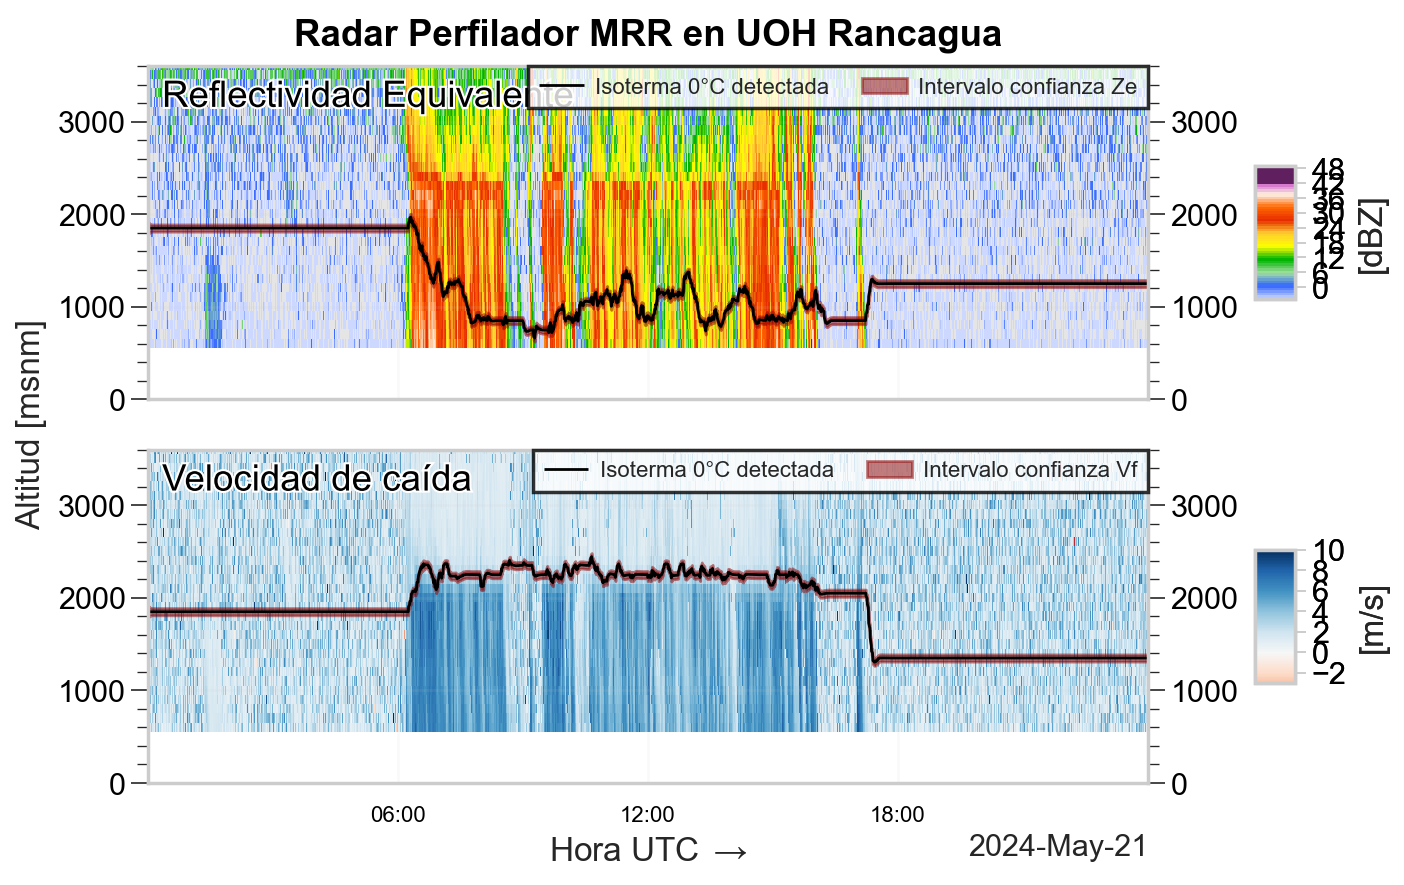

In [125]:
Ze_0521 = ds_0521['attenuated_radar_reflectivity'].T 
IndicesIsoterma_0521=[]
for resultado in resultados_isoterma_Ze_0521:
    t = resultado["iter"]
    altura_minima = resultado["altura_minima"]
    idx_altura = int((np.abs(heights_ajustado_0521 - altura_minima)).argmin())
    IndicesIsoterma_0521.append(idx_altura)

FactorConversion_0521 = (heights_0521[-1].values-500)/ len(heights_0521)
AlturasIsoterma_0521 = np.array(IndicesIsoterma_0521) * FactorConversion_0521

altura_inicial_desfase_0521 = 500 + (heights_0521[1].values - heights_0521[0].values) / 2
AlturasIsoterma_ajustadas_0521 = AlturasIsoterma_0521 + altura_inicial_desfase_0521

alturas_filtradas_0521, ganancias_0521, var_altura_0521, var_velocidad_0521, covar_0521, tasa_cambio_0521, gradientes_ponderados_Ze_0521 = filtro_kalman(AlturasIsoterma_ajustadas_0521, gradiente_Ze_0521,
                                   delta_t, 
                                   Q_ruido_proceso_reflectividad, 
                                   Q_ruido_proceso_gradiente, 
                                   R_ruido_medicion, 
                                   heights_ajustado_0521)

# Convertir la lista a array por si acaso
covarianzas_0521 = np.array(var_altura_0521)
desviacion_std_0521 = np.sqrt(covarianzas_0521)

# Intervalos de confianz
superior_0521 = alturas_filtradas_0521 + desviacion_std_0521
inferior_0521 = alturas_filtradas_0521 - desviacion_std_0521

IndicesIsoterma_Vf_0521=[]
for resultado in resultados_isoterma_Vf_0521:
    t = resultado["iter"]
    altura_minima = resultado["altura_minima"]
    idx_altura = int((np.abs(heights_ajustado_0521 - altura_minima)).argmin())
    IndicesIsoterma_Vf_0521.append(idx_altura)

AlturasIsoterma_Vf_0521 = np.array(IndicesIsoterma_Vf_0521) * FactorConversion_0521

AlturasIsoterma_ajustadas_Vf_0521 = AlturasIsoterma_Vf_0521 + altura_inicial_desfase_0521

alturas_filtradas_Vf_0521, ganancias_Vf_0521, var_altura_Vf_0521, var_velocidad_Vf_0521, covar_Vf_0521, tasa_cambio_Vf_0521, gradientes_ponderados_Vf_0521 = filtro_kalman(AlturasIsoterma_ajustadas_Vf_0521, gradiente_Vf_0521,
                                   delta_t, 
                                   Q_ruido_proceso_reflectividad, 
                                   Q_ruido_proceso_gradiente, 
                                   R_ruido_medicion, 
                                   heights_ajustado_0521)

# Convertir la lista a array por si acaso
covarianzas_Vf_0521 = np.array(var_altura_Vf_0521)
desviacion_std_Vf_0521 = np.sqrt(covarianzas_Vf_0521)

# Intervalos de confianz
superior_Vf_0521 = alturas_filtradas_Vf_0521 + desviacion_std_Vf_0521
inferior_Vf_0521 = alturas_filtradas_Vf_0521 - desviacion_std_Vf_0521

N_0521 = len(new_time_0521)
alturas_filtradas_0521 = ajustar_largo(alturas_filtradas_0521, N_0521)
superior_0521 = ajustar_largo(superior_0521, N_0521)
inferior_0521 = ajustar_largo(inferior_0521, N_0521)

alturas_filtradas_Vf_0521 = ajustar_largo(alturas_filtradas_Vf_0521, N_0521)
superior_Vf_0521 = ajustar_largo(superior_Vf_0521, N_0521)
inferior_Vf_0521 = ajustar_largo(inferior_Vf_0521, N_0521)

plot_mrr_Isotermas4(
    xlim=xlim_0521,
    times=new_time_0521,
    heights=heights_0521,
    Ze=Ze_0521.T,
    isoterma_Ze=alturas_filtradas_0521,  # Línea de isoterma filtrada
    Vf=Vf_0521,
    isoterma_Vf=alturas_filtradas_Vf_0521,
    hora_local=False,
    sd_sup_Ze=superior_0521,
    sd_inf_Ze=inferior_0521,
    sd_sup_Vf=superior_Vf_0521,
    sd_inf_Vf=inferior_Vf_0521
)

Visualización diferencia entre aproximación por método del gradiente y filtro de Kalman (reflectividad)

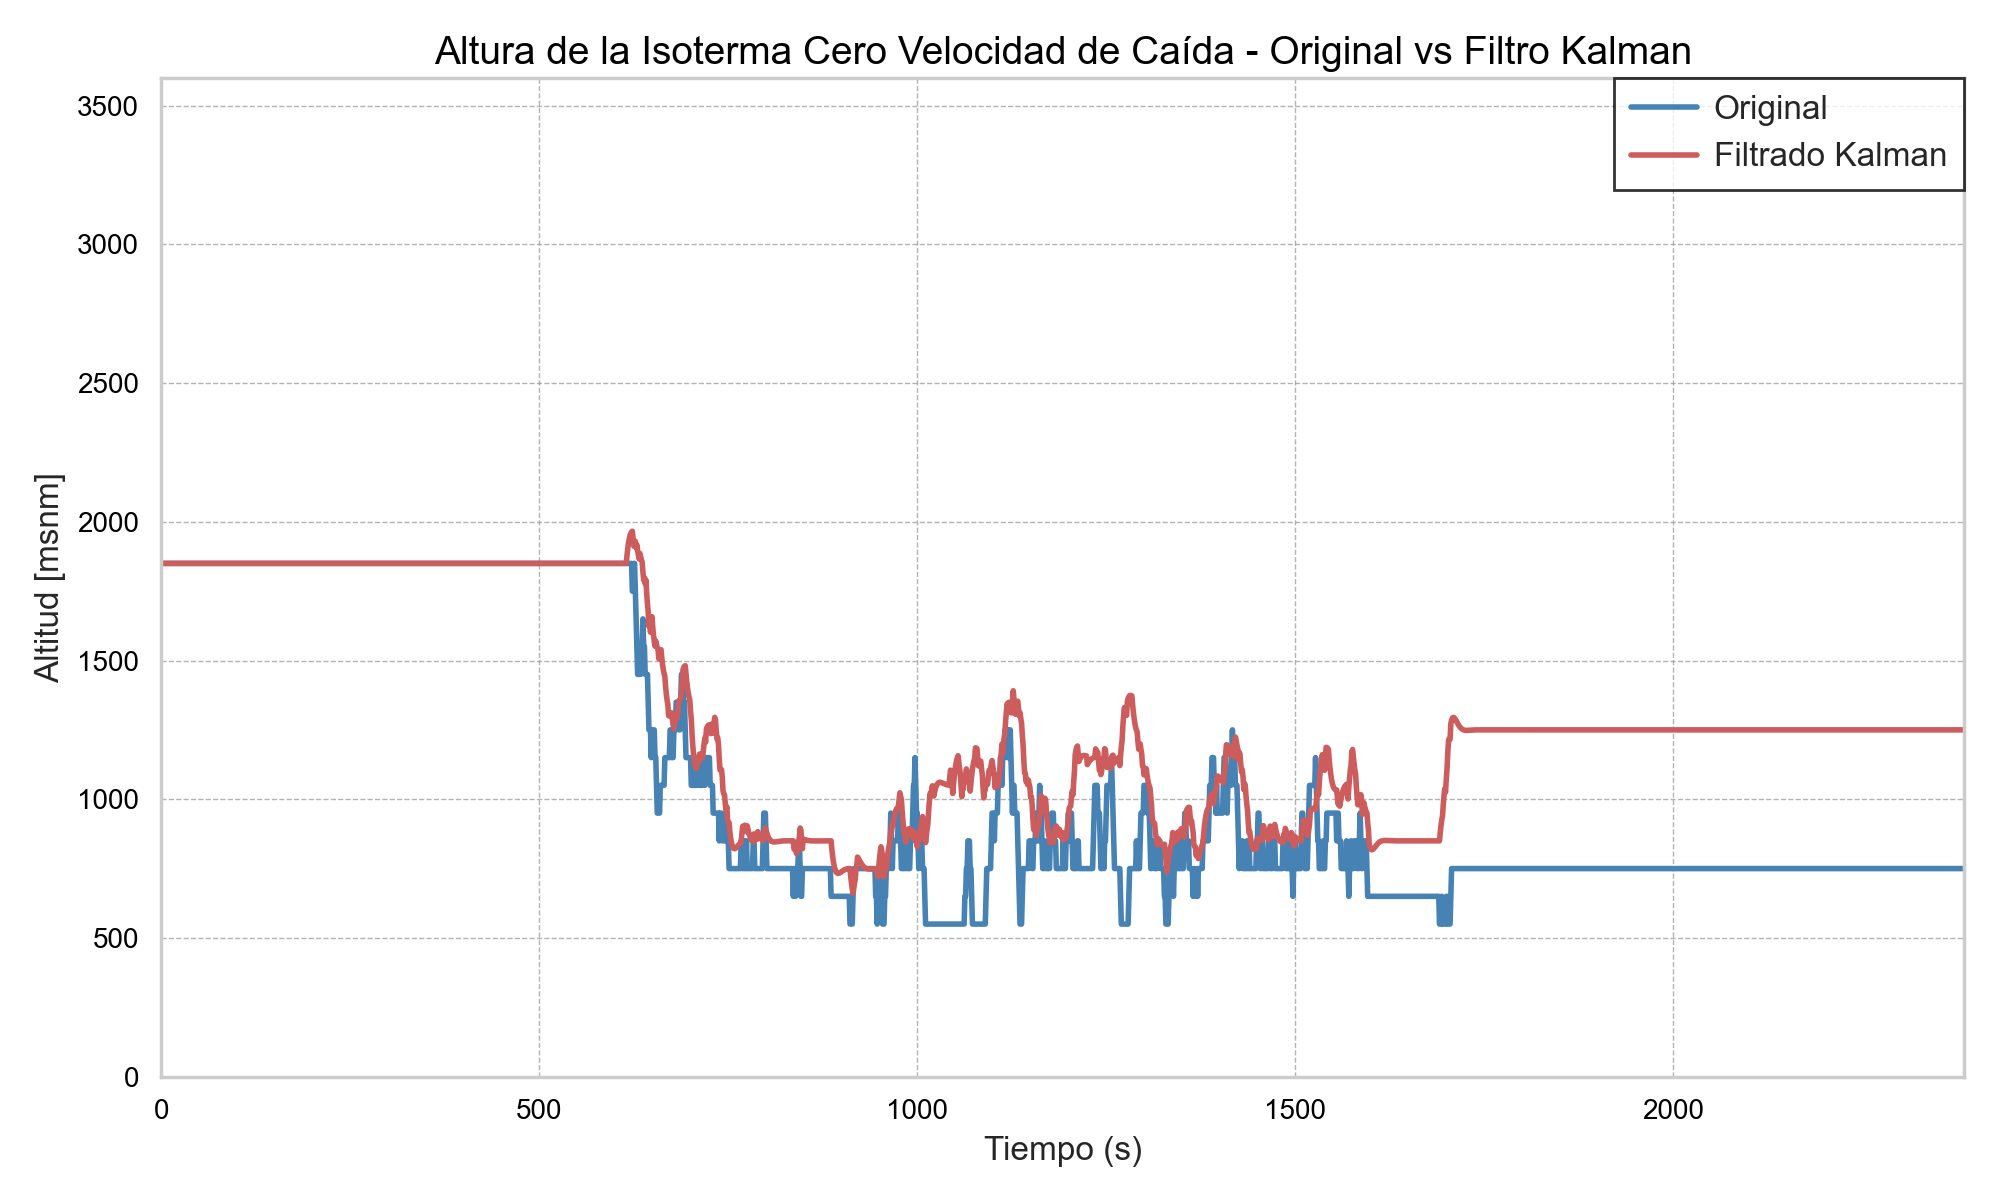

In [126]:
fig, ax = plt.subplots(figsize=(10, 6))  
ax.plot(AlturasIsoterma_ajustadas_0521, label="Original", linestyle='-', color='steelblue', linewidth=2)
ax.plot(alturas_filtradas_0521, label="Filtrado Kalman", linestyle='-', color='indianred', linewidth=2)
ax.set_xlabel('Tiempo (s)', fontsize=12) 
ax.set_ylabel('Altitud [msnm]', fontsize=12)
ax.set_title('Altura de la Isoterma Cero Velocidad de Caída - Original vs Filtro Kalman', fontsize=14)
ax.set_xlim([0, len(AlturasIsoterma_0521)])  
ax.set_ylim([0, heights_0521[-1]])    #Quité el .values porque me tiraba error
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.tick_params(axis='both', which='minor', labelsize=8)
plt.tight_layout()  
plt.show()

Visualización tasa de cambio del filtro

Visualización cercana de isoterma cero e intervalo de confianza detectado por el filtro de Kalman

Visualización diferencia entre aproximación por método del gradiente y filtro de Kalman

Visualización tasa de cambio del filtro

Visualización cercana de isoterma cero e intervalo de confianza detectado por el filtro de Kalman